# Publication-Ready EEG-Only Figures
## Nature Neuroscience Style | Figures 1 & 2

---

**Analysis:** EEG-based clustering reveals language-associated neural subtypes (N=257)

**Figures Generated:**
- **Figure 1:** EEG clustering with lateralization patterns and demographics (3 panels)
- **Figure 2:** Language outcome associations across EEG subtypes (4 panels)

**Styling:** All figures follow Nature Neuroscience formatting guidelines with Arial font, consistent color palette, and 300 DPI resolution.

---

In [41]:
"""
═══════════════════════════════════════════════════════════════════════════════
SECTION 1: SETUP & CONFIGURATION
═══════════════════════════════════════════════════════════════════════════════
"""

# Core imports
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle, FancyBboxPatch
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import (kruskal, chi2_contingency, mannwhitneyu, 
                         shapiro, levene, f_oneway, ttest_1samp)
from scipy.cluster.hierarchy import dendrogram, linkage
import scikit_posthocs as sp
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# MICE imputation for missing data
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler

print("✓ All libraries loaded successfully")

✓ All libraries loaded successfully


## SECTION 2: NATURE NEUROSCIENCE STYLING CONFIGURATION

In [24]:

# Define custom color palette (Nature-inspired, colorblind-friendly)
PALETTE = {
    'Subtype 1': (238/255, 203/255, 139/255),  # Warm beige/mustard
    'Subtype 2': (89/255, 143/255, 159/255),   # Deep teal/blue (#598F9F)
    'Subtype 3': (129/255, 157/255, 148/255),  # Green-gray (#819D94)
    'Subtype 4': (230/255, 150/255, 130/255)   # Coral/salmon
}

PALETTE_LIST = [
    (238/255, 203/255, 139/255),  # Subtype 1 - Mustard
    (89/255, 143/255, 159/255),   # Subtype 2 - Blue (#598F9F)
    (129/255, 157/255, 148/255),  # Subtype 3 - Green-gray (#819D94)
    (230/255, 150/255, 130/255)   # Subtype 4 - Salmon
]

# Nature Neuroscience styling parameters
plt.rcParams.update({
    # Font settings (Arial, standard for Nature journals)
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    
    # Line widths
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.0,
    'patch.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    
    # Figure settings
    'figure.dpi': 300,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    
    # Grid and spines
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    
    # Legend
    'legend.frameon': False,
    'legend.loc': 'best'
})

print("✓ Nature Neuroscience styling configured")
print(f"✓ Color palette: {len(PALETTE_LIST)} subtypes")

✓ Nature Neuroscience styling configured
✓ Color palette: 4 subtypes


---
## DATA LOADING
---

In [25]:
"""
═══════════════════════════════════════════════════════════════════════════════
SECTION 3: DATA LOADING
═══════════════════════════════════════════════════════════════════════════════
"""

# Define paths
BASE_PATH = Path("C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs")
HC_FILE = BASE_PATH / "outputs/hc/eeg_hc_data.csv"
DEMO_FILE = BASE_PATH / "outputs/lpa/eeg/eeg_et_lpa_demo_data.csv"
CLINICAL_FILE = BASE_PATH / "outputs/lpa/eeg/eeg_et_lpa_clinical_data.csv"
LANG_FILE = BASE_PATH / "outputs/clinical/language_measures.csv"
FIGURE_OUTPUT = BASE_PATH / "figures"

# Load the NORMALIZED EEG data from original analysis (already MICE-imputed)
NORMALIZED_EEG_FILE = BASE_PATH / "code/clustering/combined_data_EEG.csv"

# Load clustering data
hc_data = pd.read_csv(HC_FILE)[['subject', 'cluster4dcom']]
hc_data = hc_data.rename(columns={'cluster4dcom': 'hc_cluster'})

# Load demographics
demo_data = pd.read_csv(DEMO_FILE)

# Load NORMALIZED EEG data (MICE-imputed from original analysis)
normalized_eeg = pd.read_csv(NORMALIZED_EEG_FILE)
print(f"✓ Loaded normalized EEG data: {len(normalized_eeg)} subjects")
print(f"  Variables: {list(normalized_eeg.columns)}")

# Load clinical/EEG data
clinical_data = pd.read_csv(CLINICAL_FILE)
clinical_data = clinical_data[[
    'subject',
    # EEG measures
    'l_index_frontal', 'log_gamma_frontal_abs', 'log_con',
    # Clinical measures
    'tscore_total', 'tscore_communication',
    # Additional
    'facilitation', 'disengagement'
]]

# Load language measures
lang_data = pd.read_csv(LANG_FILE)

# Merge all datasets
merged_data = (hc_data
               .merge(demo_data, on='subject', how='left')
               .merge(clinical_data, on='subject', how='left')
               .merge(lang_data, on='subject', how='left'))

# Sample size
n_total = len(merged_data)
n_by_cluster = merged_data['hc_cluster'].value_counts().sort_index()

print(f"✓ Data loaded: N={n_total}")
print(f"✓ Cluster distribution:")
for cluster, n in n_by_cluster.items():
    pct = (n/n_total)*100
    print(f"  Subtype {int(cluster)}: n={n} ({pct:.1f}%)")

✓ Loaded normalized EEG data: 257 subjects
  Variables: ['l_index_frontal', 'log_gamma_frontal_abs', 'log_con']
✓ Data loaded: N=257
✓ Cluster distribution:
  Subtype 0: n=131 (51.0%)
  Subtype 1: n=29 (11.3%)
  Subtype 2: n=25 (9.7%)
  Subtype 3: n=72 (28.0%)


In [26]:
# Quick data preview
display(merged_data.head())
print(f"\nTotal columns: {len(merged_data.columns)}")
print(f"Key variables available: {list(merged_data.columns[:10])}")

,subject,hc_cluster,eeg_age,site,sex,asd,ndd,group,age_group,fam_id,...,weschler_verbal_rank,ppvt5_ss,evt3_ss,history_language_impairments,non_verbal_language_impairment,expressive_language_delay,receptive_language_delay,age_first_words,age_first_sentences,age_respond_to_name
0,1089P,2,7.19,hsj,female,1.0,ndd,proband,child,1089,...,0.3,NaN,NaN,1.0,0.0,1.0,1.0,late,late,late
1,1093S2,3,4.20,hsj,female,1.0,control,sibling,child,1093,...,88.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0150P,0,10.21,hsj,male,1.0,ndd,proband,child,150,...,66.0,NaN,NaN,1.0,0.0,1.0,1.0,late,late,late
3,1256S1,0,17.33,hsj,male,1.0,ndd,sibling,child,1256,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,early,early,early
4,0126P,0,8.29,hsj,male,1.0,ndd,proband,child,126,...,30.0,NaN,NaN,1.0,0.0,1.0,0.0,early,early,early



Total columns: 31
Key variables available: ['subject', 'hc_cluster', 'eeg_age', 'site', 'sex', 'asd', 'ndd', 'group', 'age_group', 'fam_id']


---
## DATA PREPARATION
---

In [27]:
"""
═══════════════════════════════════════════════════════════════════════════════
SECTION 4: DATA PREPARATION & VARIABLE DEFINITIONS
═══════════════════════════════════════════════════════════════════════════════
"""

# Define variable groupings
EEG_VARS = ['l_index_frontal', 'log_gamma_frontal_abs', 'log_con']

LANGUAGE_CONTINUOUS = [
    'abas_communication',  # ABAS Communication scale
    'wechsler_viq_percentile'  # Verbal IQ
]

LANGUAGE_CATEGORICAL = [
    'age_first_words',
    'age_first_sentences', 
    'respond_to_name',
    'history_nonverbal_impairment',
    'history_expressive_delay',
    'history_receptive_delay'
]

DEMOGRAPHICS = ['eeg_age', 'sex', 'asd_diagnosis']

# Variable display names for figures
VAR_NAMES = {
    'l_index_frontal': 'Frontal Lateralization Index',
    'log_gamma_frontal_abs': 'Gamma Power (log, age-adjusted)',
    'log_con': 'Connectivity (log)',
    'abas_communication': 'ABAS Communication',
    'wechsler_viq_percentile': 'Wechsler VIQ (%ile)',
    'eeg_age': 'Age (years)',
    'sex': 'Sex',
    'asd_diagnosis': 'ASD Diagnosis',
    'age_first_words': 'Age First Words',
    'age_first_sentences': 'Age First Sentences',
    'respond_to_name': 'Respond to Name',
    'history_nonverbal_impairment': 'Nonverbal Impairment History',
    'history_expressive_delay': 'Expressive Delay History',
    'history_receptive_delay': 'Receptive Delay History'
}

# Create clean cluster labels
merged_data['subtype'] = merged_data['hc_cluster'].map({
    0: 'Subtype 1',
    1: 'Subtype 2',
    2: 'Subtype 3',
    3: 'Subtype 4'
})

print("✓ Variables organized for analysis")
print(f"  EEG variables: {len(EEG_VARS)}")
print(f"  Continuous language outcomes: {len(LANGUAGE_CONTINUOUS)}")
print(f"  Categorical language outcomes: {len(LANGUAGE_CATEGORICAL)}")

✓ Variables organized for analysis
  EEG variables: 3
  Continuous language outcomes: 2
  Categorical language outcomes: 6


In [45]:
"""
═══════════════════════════════════════════════════════════════════════════════
FIGURE 4 DATA PREPARATION: NORMALIZE EEG MEASURES FOR PROFILE COMPARISON
═══════════════════════════════════════════════════════════════════════════════
"""

print("="*70)
print("FIGURE 4: EEG SUBTYPE PROFILES")
print("="*70)

# Prepare data: normalize each EEG measure to z-scores for comparability
eeg_profile_data = merged_data[['hc_cluster', 'subtype'] + EEG_VARS].dropna()

print(f"\n✓ Data prepared: N={len(eeg_profile_data)} subjects with complete EEG data")
print(f"  Variables: {EEG_VARS}")

# Z-score normalize each measure
normalized_measures = eeg_profile_data.copy()
for var in EEG_VARS:
    normalized_measures[f'{var}_z'] = stats.zscore(eeg_profile_data[var])

# Calculate means and 95% CI for each subtype
profile_stats = []
for cluster in range(4):
    cluster_data = normalized_measures[normalized_measures['hc_cluster'] == cluster]
    for var in EEG_VARS:
        z_var = f'{var}_z'
        values = cluster_data[z_var].values
        mean = np.mean(values)
        sem = stats.sem(values)
        ci_95 = 1.96 * sem
        
        profile_stats.append({
            'subtype': f'Subtype {cluster + 1}',
            'cluster': cluster,
            'measure': var,
            'measure_name': VAR_NAMES[var],
            'mean_z': mean,
            'ci_lower': mean - ci_95,
            'ci_upper': mean + ci_95,
            'n': len(values)
        })

profile_df = pd.DataFrame(profile_stats)

# Display summary
print("\n" + "="*70)
print("NORMALIZED EEG PROFILE SUMMARY (z-scores)")
print("="*70)
pivot_table = profile_df.pivot_table(index='measure_name', columns='subtype', values='mean_z')
display(pivot_table.round(2))
print("\n✓ Data normalized and aggregated by subtype")

FIGURE 4: EEG SUBTYPE PROFILES

✓ Data prepared: N=257 subjects with complete EEG data
  Variables: ['l_index_frontal', 'log_gamma_frontal_abs', 'log_con']

NORMALIZED EEG PROFILE SUMMARY (z-scores)


subtype,Subtype 1,Subtype 2,Subtype 3,Subtype 4
measure_name,,,,
Connectivity (log),-0.24,1.14,-0.79,0.26
Frontal Lateralization Index,0.54,0.27,0.02,-1.11
"Gamma Power (log, age-adjusted)",-0.41,0.65,1.03,0.13



✓ Data normalized and aggregated by subtype


---
## STATISTICAL TESTING FUNCTIONS
---

In [28]:
"""
═══════════════════════════════════════════════════════════════════════════════
SECTION 5: STATISTICAL ANALYSIS FUNCTIONS
═══════════════════════════════════════════════════════════════════════════════
"""

def compute_eta_squared(groups):
    """Compute eta-squared effect size for Kruskal-Wallis"""
    n_total = sum(len(g) for g in groups)
    ranks = stats.rankdata(np.concatenate(groups))
    
    # Split ranks back into groups
    rank_groups = []
    idx = 0
    for g in groups:
        rank_groups.append(ranks[idx:idx+len(g)])
        idx += len(g)
    
    # Compute H statistic components
    mean_ranks = [np.mean(rg) for rg in rank_groups]
    grand_mean = (n_total + 1) / 2
    
    ss_between = sum(len(g) * (mr - grand_mean)**2 for g, mr in zip(groups, mean_ranks))
    ss_total = sum((r - grand_mean)**2 for r in ranks)
    
    return ss_between / ss_total if ss_total > 0 else 0


def comprehensive_test_continuous(df, var, group_col='hc_cluster'):
    """
    Perform comprehensive statistical testing for continuous variables
    Returns test type, statistic, p-value, and effect size
    """
    # Clean data
    test_data = df[[group_col, var]].dropna()
    test_data[var] = pd.to_numeric(test_data[var], errors='coerce')
    test_data = test_data.dropna()
    
    if len(test_data) < 10:
        return {'test': 'Insufficient data', 'statistic': np.nan, 'p_value': np.nan, 'effect_size': np.nan}
    
    # Group data
    groups = [test_data[test_data[group_col] == cluster][var].values 
              for cluster in sorted(test_data[group_col].unique())]
    
    # Perform Kruskal-Wallis test (non-parametric)
    H, p_value = kruskal(*groups)
    eta_sq = compute_eta_squared(groups)
    
    return {
        'test': 'Kruskal-Wallis',
        'statistic': H,
        'p_value': p_value,
        'effect_size': eta_sq,
        'n': len(test_data)
    }


def comprehensive_test_categorical(df, var, group_col='hc_cluster'):
    """
    Perform chi-square test for categorical variables
    Returns test type, statistic, p-value, and effect size (Cramér's V)
    """
    # Clean data
    test_data = df[[group_col, var]].dropna()
    
    if len(test_data) < 10:
        return {'test': 'Insufficient data', 'statistic': np.nan, 'p_value': np.nan, 'effect_size': np.nan}
    
    # Create contingency table
    contingency = pd.crosstab(test_data[group_col], test_data[var])
    
    # Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    # Cramér's V effect size
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan
    
    return {
        'test': 'Chi-square',
        'statistic': chi2,
        'p_value': p_value,
        'effect_size': cramers_v,
        'df': dof,
        'n': n
    }


def one_sample_ttest_lateralization(df, cluster, var='l_index_frontal'):
    """
    Test if lateralization index differs from zero for a specific cluster
    """
    data = df[df['hc_cluster'] == cluster][var].dropna()
    
    if len(data) < 5:
        return {'t': np.nan, 'p': np.nan, 'mean': np.nan, 'n': len(data)}
    
    t_stat, p_val = ttest_1samp(data, 0)
    
    return {
        't': t_stat,
        'p': p_val,
        'mean': data.mean(),
        'sem': data.sem(),
        'n': len(data)
    }

print("✓ Statistical functions defined")

✓ Statistical functions defined


# **MAIN PUBLICATION FIGURES**

### **Figure 1** Methodology + dendogram + demographics

COMPREHENSIVE METHODOLOGY PANEL
✓ Panel A placeholder created
✓ Dendrogram recreated
✓ Demographics recreated (Age, Sex, ASD - all in one row)


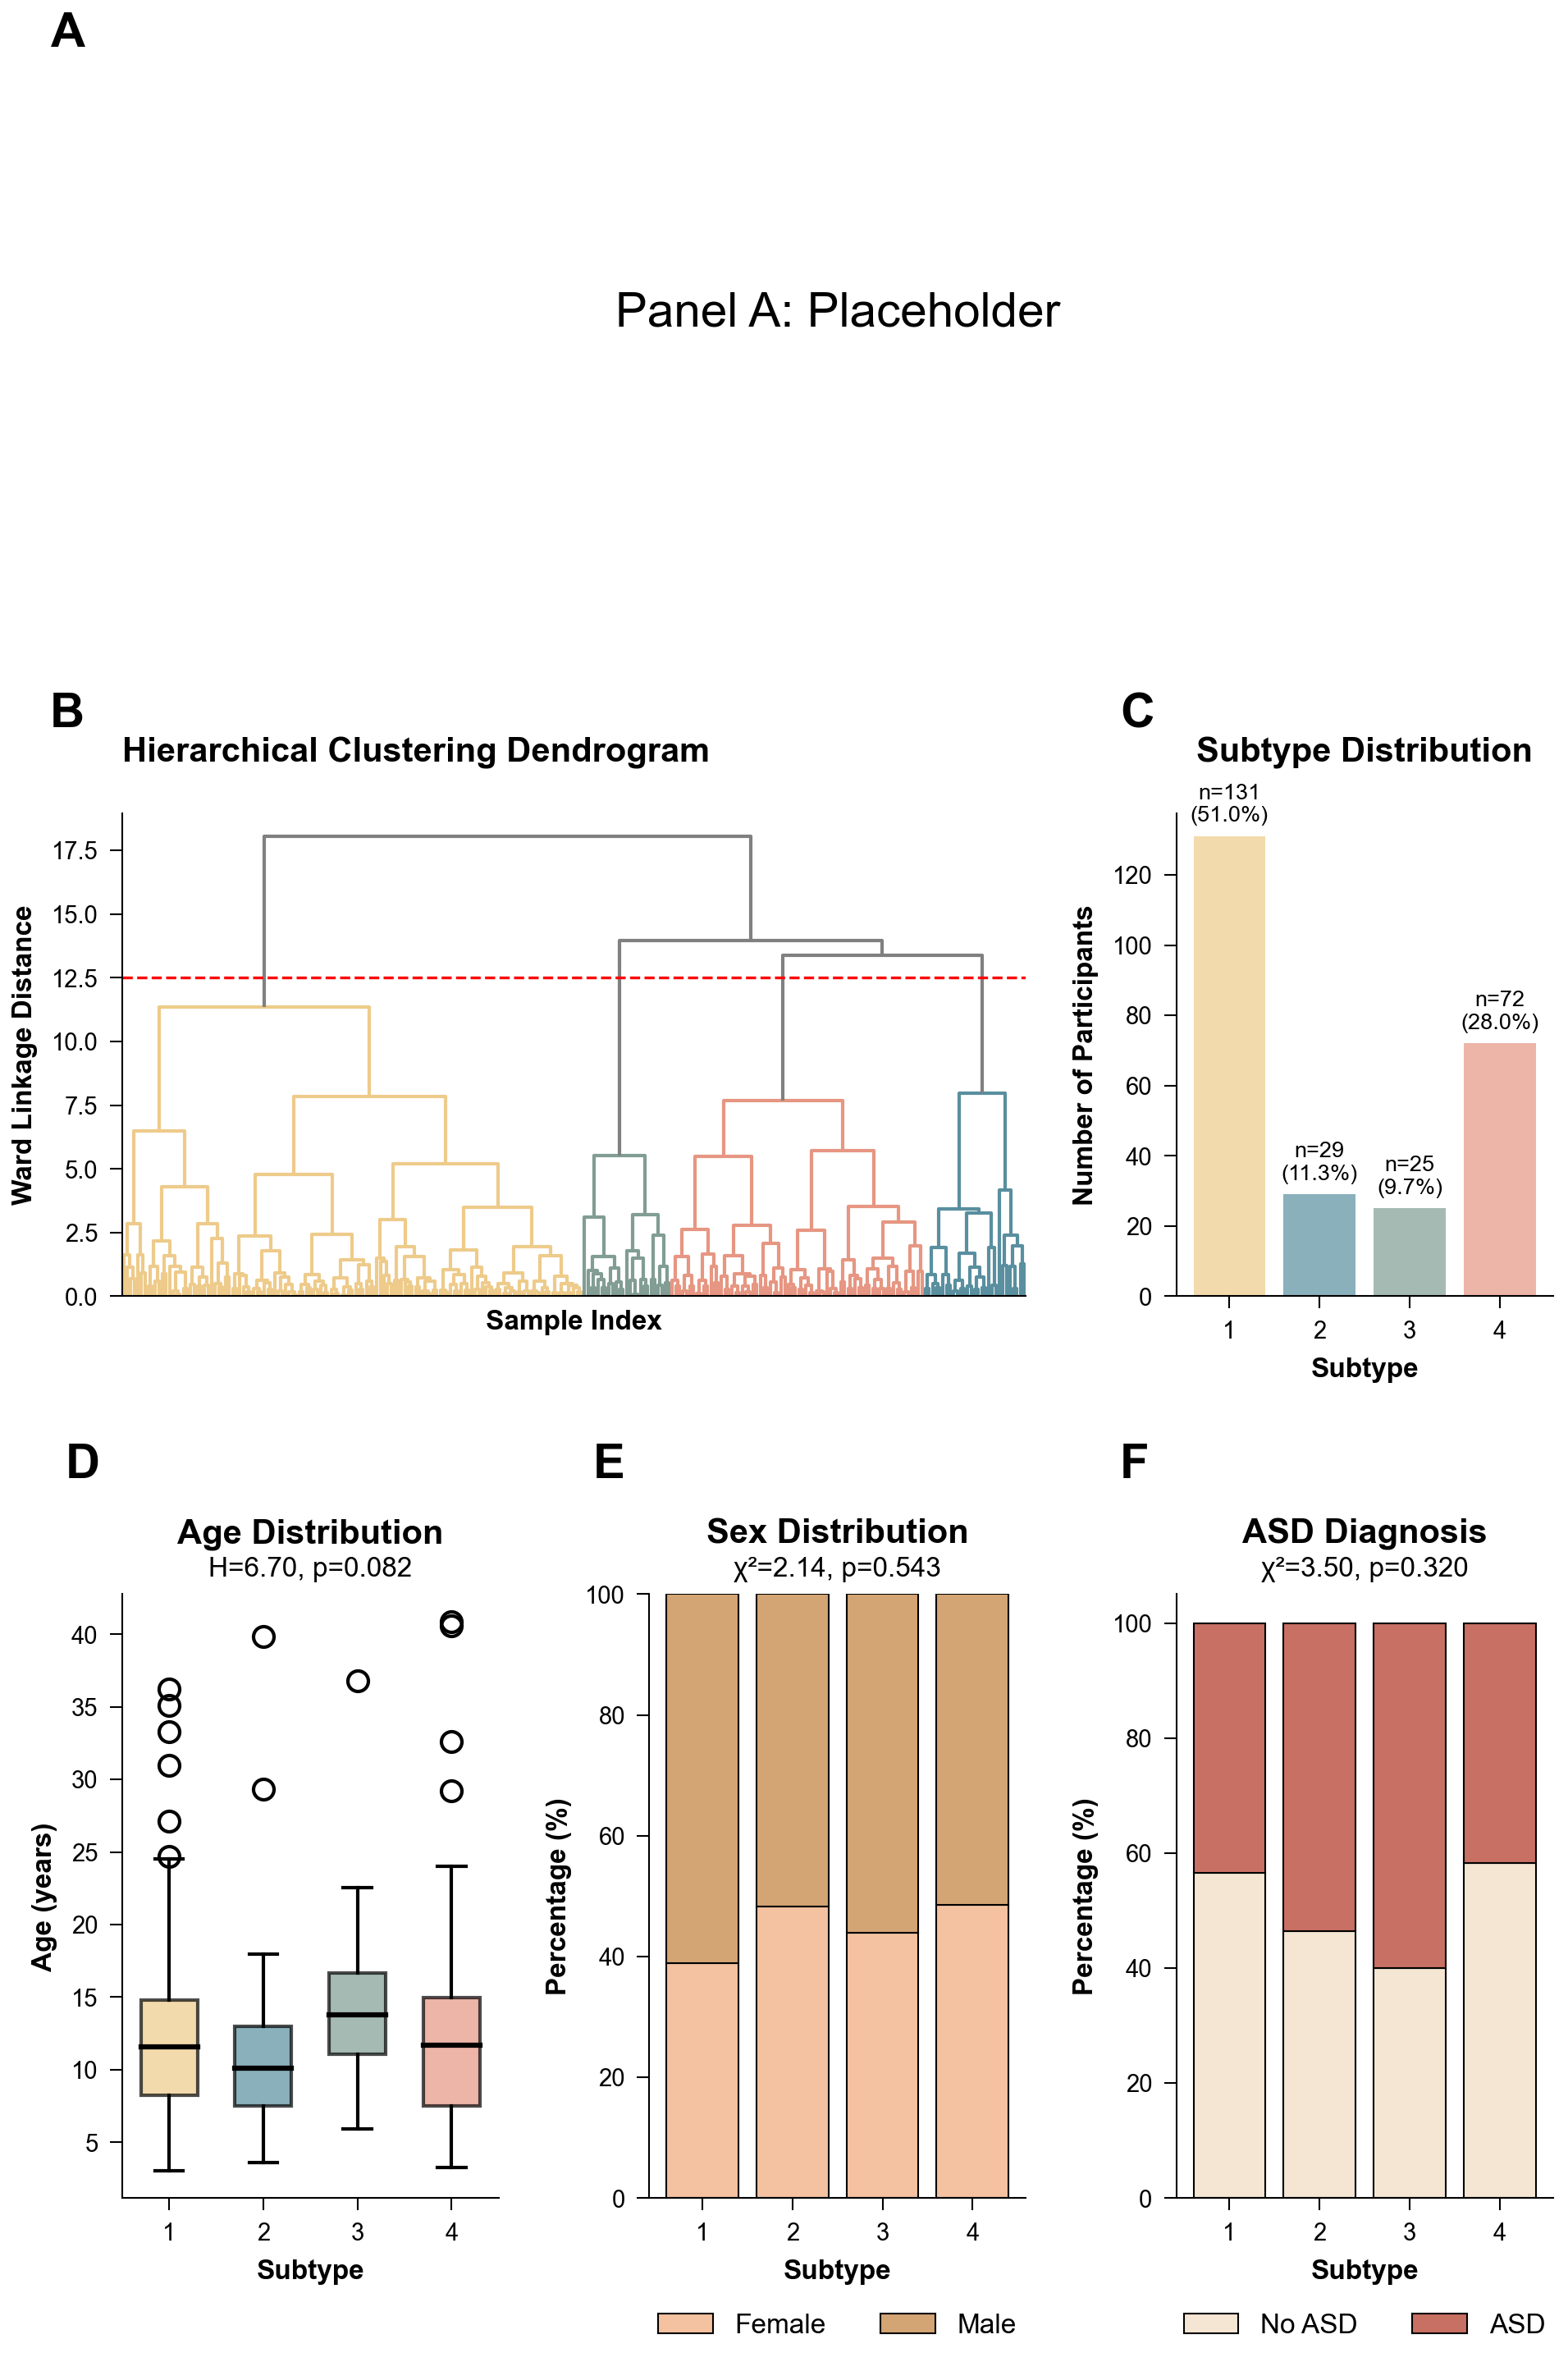


✓ Comprehensive Methodology Panel generated
  Panel 1: Methodology outline (PNG)


In [40]:

from matplotlib import image as mpimg
from PIL import Image

print("="*70)
print("COMPREHENSIVE METHODOLOGY PANEL")
print("="*70)

# Paths
methodology_path = Path(r"C:\Users\gabot\OneDrive - McGill University\Desktop\Github_repos\q1k_neurosubs\figures\Figure1A methodology.png")

# Create figure with GridSpec for custom layout
fig = plt.figure(figsize=(7.5, 11))
gs = GridSpec(3, 3, figure=fig, 
              height_ratios=[1, 1.2, 1.5],  # Methodology, Dendrogram, Demographics
              width_ratios=[1, 1, 1],
              hspace=0.6, wspace=0.4)

# ============================================================================
# PANEL 1: METHODOLOGY OUTLINE (Full width at top)
# ============================================================================
ax_method = fig.add_subplot(gs[0, :])

# Placeholder for Panel A
ax_method.text(0.5, 0.5, 'Panel A: Placeholder',
              ha='center', va='center', fontsize=14, 
              transform=ax_method.transAxes)
ax_method.axis('off')
# Add panel label A (with lots of padding above)
ax_method.text(-0.05, 1.25, 'A', transform=ax_method.transAxes,
              fontsize=14, fontweight='bold', va='top', ha='left')
print("✓ Panel A placeholder created")

# ============================================================================
# PANEL 2: DENDROGRAM + CLUSTER SIZES (Recreate from original code)
# ============================================================================

# Dendrogram subplot (spans first 2 columns)
ax_dend = fig.add_subplot(gs[1, 0:2])

# Get normalized EEG data and compute linkage
X_scaled = normalized_eeg.values
Z_panel = linkage(X_scaled, method='ward', metric='euclidean')

# Set custom colors for dendrogram branches
from scipy.cluster.hierarchy import set_link_color_palette
palette_dendrogram = [PALETTE_LIST[0], PALETTE_LIST[2], PALETTE_LIST[3], PALETTE_LIST[1]]
palette_hex = ['#%02x%02x%02x' % (int(r*255), int(g*255), int(b*255)) for r, g, b in palette_dendrogram]
set_link_color_palette(palette_hex)
color_threshold = 12.5

dendrogram(Z_panel, ax=ax_dend, color_threshold=color_threshold, 
           above_threshold_color='gray', no_labels=True)
ax_dend.axhline(y=color_threshold, color='red', linestyle='--', 
                linewidth=0.8, label='4-cluster cutoff')
ax_dend.set_xlabel('Sample Index', fontsize=8, fontweight='bold')
ax_dend.set_ylabel('Ward Linkage Distance', fontsize=8, fontweight='bold')
ax_dend.set_title('Hierarchical Clustering Dendrogram', 
                  fontsize=10, fontweight='bold', loc='left', pad=15)
ax_dend.spines['top'].set_visible(False)
ax_dend.spines['right'].set_visible(False)

# Reset color palette
set_link_color_palette(None)

# Add panel label B (with lots of padding above)
ax_dend.text(-0.08, 1.25, 'B', transform=ax_dend.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

# Cluster sizes subplot (right column)
ax_sizes = fig.add_subplot(gs[1, 2])

cluster_counts = merged_data['subtype'].value_counts().sort_index()
n_total = len(merged_data)
bars = ax_sizes.bar(range(len(cluster_counts)), cluster_counts.values)

# Color the bars to match cluster colors
for i, bar in enumerate(bars):
    bar.set_facecolor(PALETTE_LIST[i])
    bar.set_alpha(0.7)

ax_sizes.set_title('Subtype Distribution', fontsize=10, fontweight='bold', 
                   loc='center', pad=15)
ax_sizes.set_xlabel('Subtype', fontsize=8, fontweight='bold')
ax_sizes.set_ylabel('Number of Participants', fontsize=8, fontweight='bold')
ax_sizes.set_xticks(range(len(cluster_counts)))
ax_sizes.set_xticklabels([f'{i+1}' for i in range(len(cluster_counts))])
ax_sizes.spines['top'].set_visible(False)
ax_sizes.spines['right'].set_visible(False)

# Add panel label C (with lots of padding above)
ax_sizes.text(-0.15, 1.25, 'C', transform=ax_sizes.transAxes,
             fontsize=14, fontweight='bold', va='top', ha='left')

# Add n and % labels on bars
for i, (bar, count) in enumerate(zip(bars, cluster_counts.values)):
    height = bar.get_height()
    pct = (count / n_total) * 100
    ax_sizes.text(bar.get_x() + bar.get_width()/2, height + 3,
                  f'n={count}\n({pct:.1f}%)',
                  ha='center', va='bottom', fontsize=6.5)

print("✓ Dendrogram recreated")

# ============================================================================
# PANEL 3: DEMOGRAPHICS - ALL THREE IN ONE ROW (Recreate from original code)
# ============================================================================

# Age distribution (left column)
ax_age = fig.add_subplot(gs[2, 0])
age_data = merged_data[['hc_cluster', 'eeg_age']].dropna()
age_test = comprehensive_test_continuous(merged_data, 'eeg_age')

bp1 = ax_age.boxplot([age_data[age_data['hc_cluster'] == c]['eeg_age'].values 
                       for c in sorted(age_data['hc_cluster'].unique())],
                      positions=range(4), widths=0.6, patch_artist=True)
for i, patch in enumerate(bp1['boxes']):
    patch.set_facecolor(PALETTE_LIST[i])
    patch.set_alpha(0.7)

# Set median lines to black
for median in bp1['medians']:
    median.set_color('black')
    median.set_linewidth(1.5)

ax_age.set_xlabel('Subtype', fontsize=8, fontweight='bold')
ax_age.set_ylabel('Age (years)', fontsize=8, fontweight='bold')
ax_age.set_title('Age Distribution', fontsize=10, fontweight='bold', loc='center', pad=15)
ax_age.text(0.5, 1.02, f'H={age_test["statistic"]:.2f}, p={age_test["p_value"]:.3f}',
            transform=ax_age.transAxes, fontsize=8, ha='center', va='bottom')
ax_age.set_xticks(range(4))
ax_age.set_xticklabels([f'{i+1}' for i in range(4)])
ax_age.spines['top'].set_visible(False)
ax_age.spines['right'].set_visible(False)

# Add panel label D (with lots of padding above)
ax_age.text(-0.15, 1.25, 'D', transform=ax_age.transAxes,
           fontsize=14, fontweight='bold', va='top', ha='left')

# Sex distribution (middle column)
ax_sex = fig.add_subplot(gs[2, 1])

sex_data = merged_data[['hc_cluster', 'sex']].dropna()
sex_test = comprehensive_test_categorical(merged_data, 'sex')
sex_counts = pd.crosstab(sex_data['hc_cluster'], sex_data['sex'], normalize='index') * 100

# Define warm-toned colors for sex
sex_colors = {
    'Female': '#F4C2A0', 'female': '#F4C2A0',  # Soft peach
    'Male': '#D4A574', 'male': '#D4A574'  # Warm gold
}

bottom = np.zeros(4)
for sex_val in sorted(sex_counts.columns):
    values = sex_counts[sex_val].values
    color = sex_colors.get(sex_val, '#CCC')
    label = str(sex_val).capitalize() if isinstance(sex_val, str) else sex_val
    ax_sex.bar(range(4), values, bottom=bottom, label=label,
               color=color, edgecolor='black', linewidth=0.5)
    bottom += values

ax_sex.set_xlabel('Subtype', fontsize=8, fontweight='bold')
ax_sex.set_ylabel('Percentage (%)', fontsize=8, fontweight='bold')
ax_sex.set_title('Sex Distribution', fontsize=10, fontweight='bold', loc='center', pad=15)
ax_sex.text(0.5, 1.02, f'χ²={sex_test["statistic"]:.2f}, p={sex_test["p_value"]:.3f}',
            transform=ax_sex.transAxes, fontsize=8, ha='center', va='bottom')
ax_sex.set_xticks(range(4))
ax_sex.set_xticklabels([f'{i+1}' for i in range(4)])
ax_sex.set_ylim(0, 100)
ax_sex.spines['top'].set_visible(False)
ax_sex.spines['right'].set_visible(False)

# Horizontal legend below plot
ax_sex.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.15),
              ncol=2, frameon=False)

# Add panel label E (with lots of padding above)
ax_sex.text(-0.15, 1.25, 'E', transform=ax_sex.transAxes,
           fontsize=14, fontweight='bold', va='top', ha='left')

# ASD diagnosis distribution (right column)
ax_asd = fig.add_subplot(gs[2, 2])

asd_data = merged_data[['hc_cluster', 'asd']].dropna()
asd_test = comprehensive_test_categorical(merged_data, 'asd')
asd_counts = pd.crosstab(asd_data['hc_cluster'], asd_data['asd'], normalize='index') * 100

# Define warm-toned colors for ASD diagnosis
asd_colors = {0: '#F5E6D3', 1: '#C97064'}
asd_labels = {0: 'No ASD', 1: 'ASD'}

bottom = np.zeros(4)
for asd_val in sorted(asd_counts.columns):
    values = asd_counts[asd_val].values
    ax_asd.bar(range(4), values, bottom=bottom, 
               label=asd_labels.get(asd_val, str(asd_val)),
               color=asd_colors.get(asd_val, '#CCC'),
               edgecolor='black', linewidth=0.5)
    bottom += values

ax_asd.set_xlabel('Subtype', fontsize=8, fontweight='bold')
ax_asd.set_ylabel('Percentage (%)', fontsize=8, fontweight='bold')
ax_asd.set_title('ASD Diagnosis', fontsize=10, fontweight='bold', loc='center', pad=15)
ax_asd.text(0.5, 1.02, f'χ²={asd_test["statistic"]:.2f}, p={asd_test["p_value"]:.3f}',
            transform=ax_asd.transAxes, fontsize=8, ha='center', va='bottom')
ax_asd.set_xticks(range(4))
ax_asd.set_xticklabels([f'{i+1}' for i in range(4)])

# Horizontal legend below plot
ax_asd.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.15),
              ncol=2, frameon=False)

# Add panel label F (with lots of padding above)
ax_asd.text(-0.15, 1.25, 'F', transform=ax_asd.transAxes,
           fontsize=14, fontweight='bold', va='top', ha='left')

print("✓ Demographics recreated (Age, Sex, ASD - all in one row)")

# Save combined figure
plt.savefig(FIGURE_OUTPUT / 'Comprehensive_Methodology_Panel.png', 
            dpi=300, bbox_inches='tight', pad_inches=0.3)
plt.savefig(FIGURE_OUTPUT / 'Comprehensive_Methodology_Panel.pdf', 
            bbox_inches='tight', pad_inches=0.3)
plt.show()

print("\n✓ Comprehensive Methodology Panel generated")
print(f"  Panel 1: Methodology outline (PNG)")







### **Figure 2** EEG Measures

**Four-panel figure showing:**
- Panel A: Parallel coordinates plot (top, full width)
- Panel B: Lateralization violin plot (bottom left)
- Panel C: Gamma Power violin plot (bottom center)
- Panel D: Connectivity violin plot (bottom right)

COMBINED EEG MEASURES PANEL
✓ Panel A: Parallel coordinates plot created
✓ Panel B: Lateralization violin plot created
✓ Panel C: Gamma power violin plot created
✓ Panel D: Connectivity violin plot created


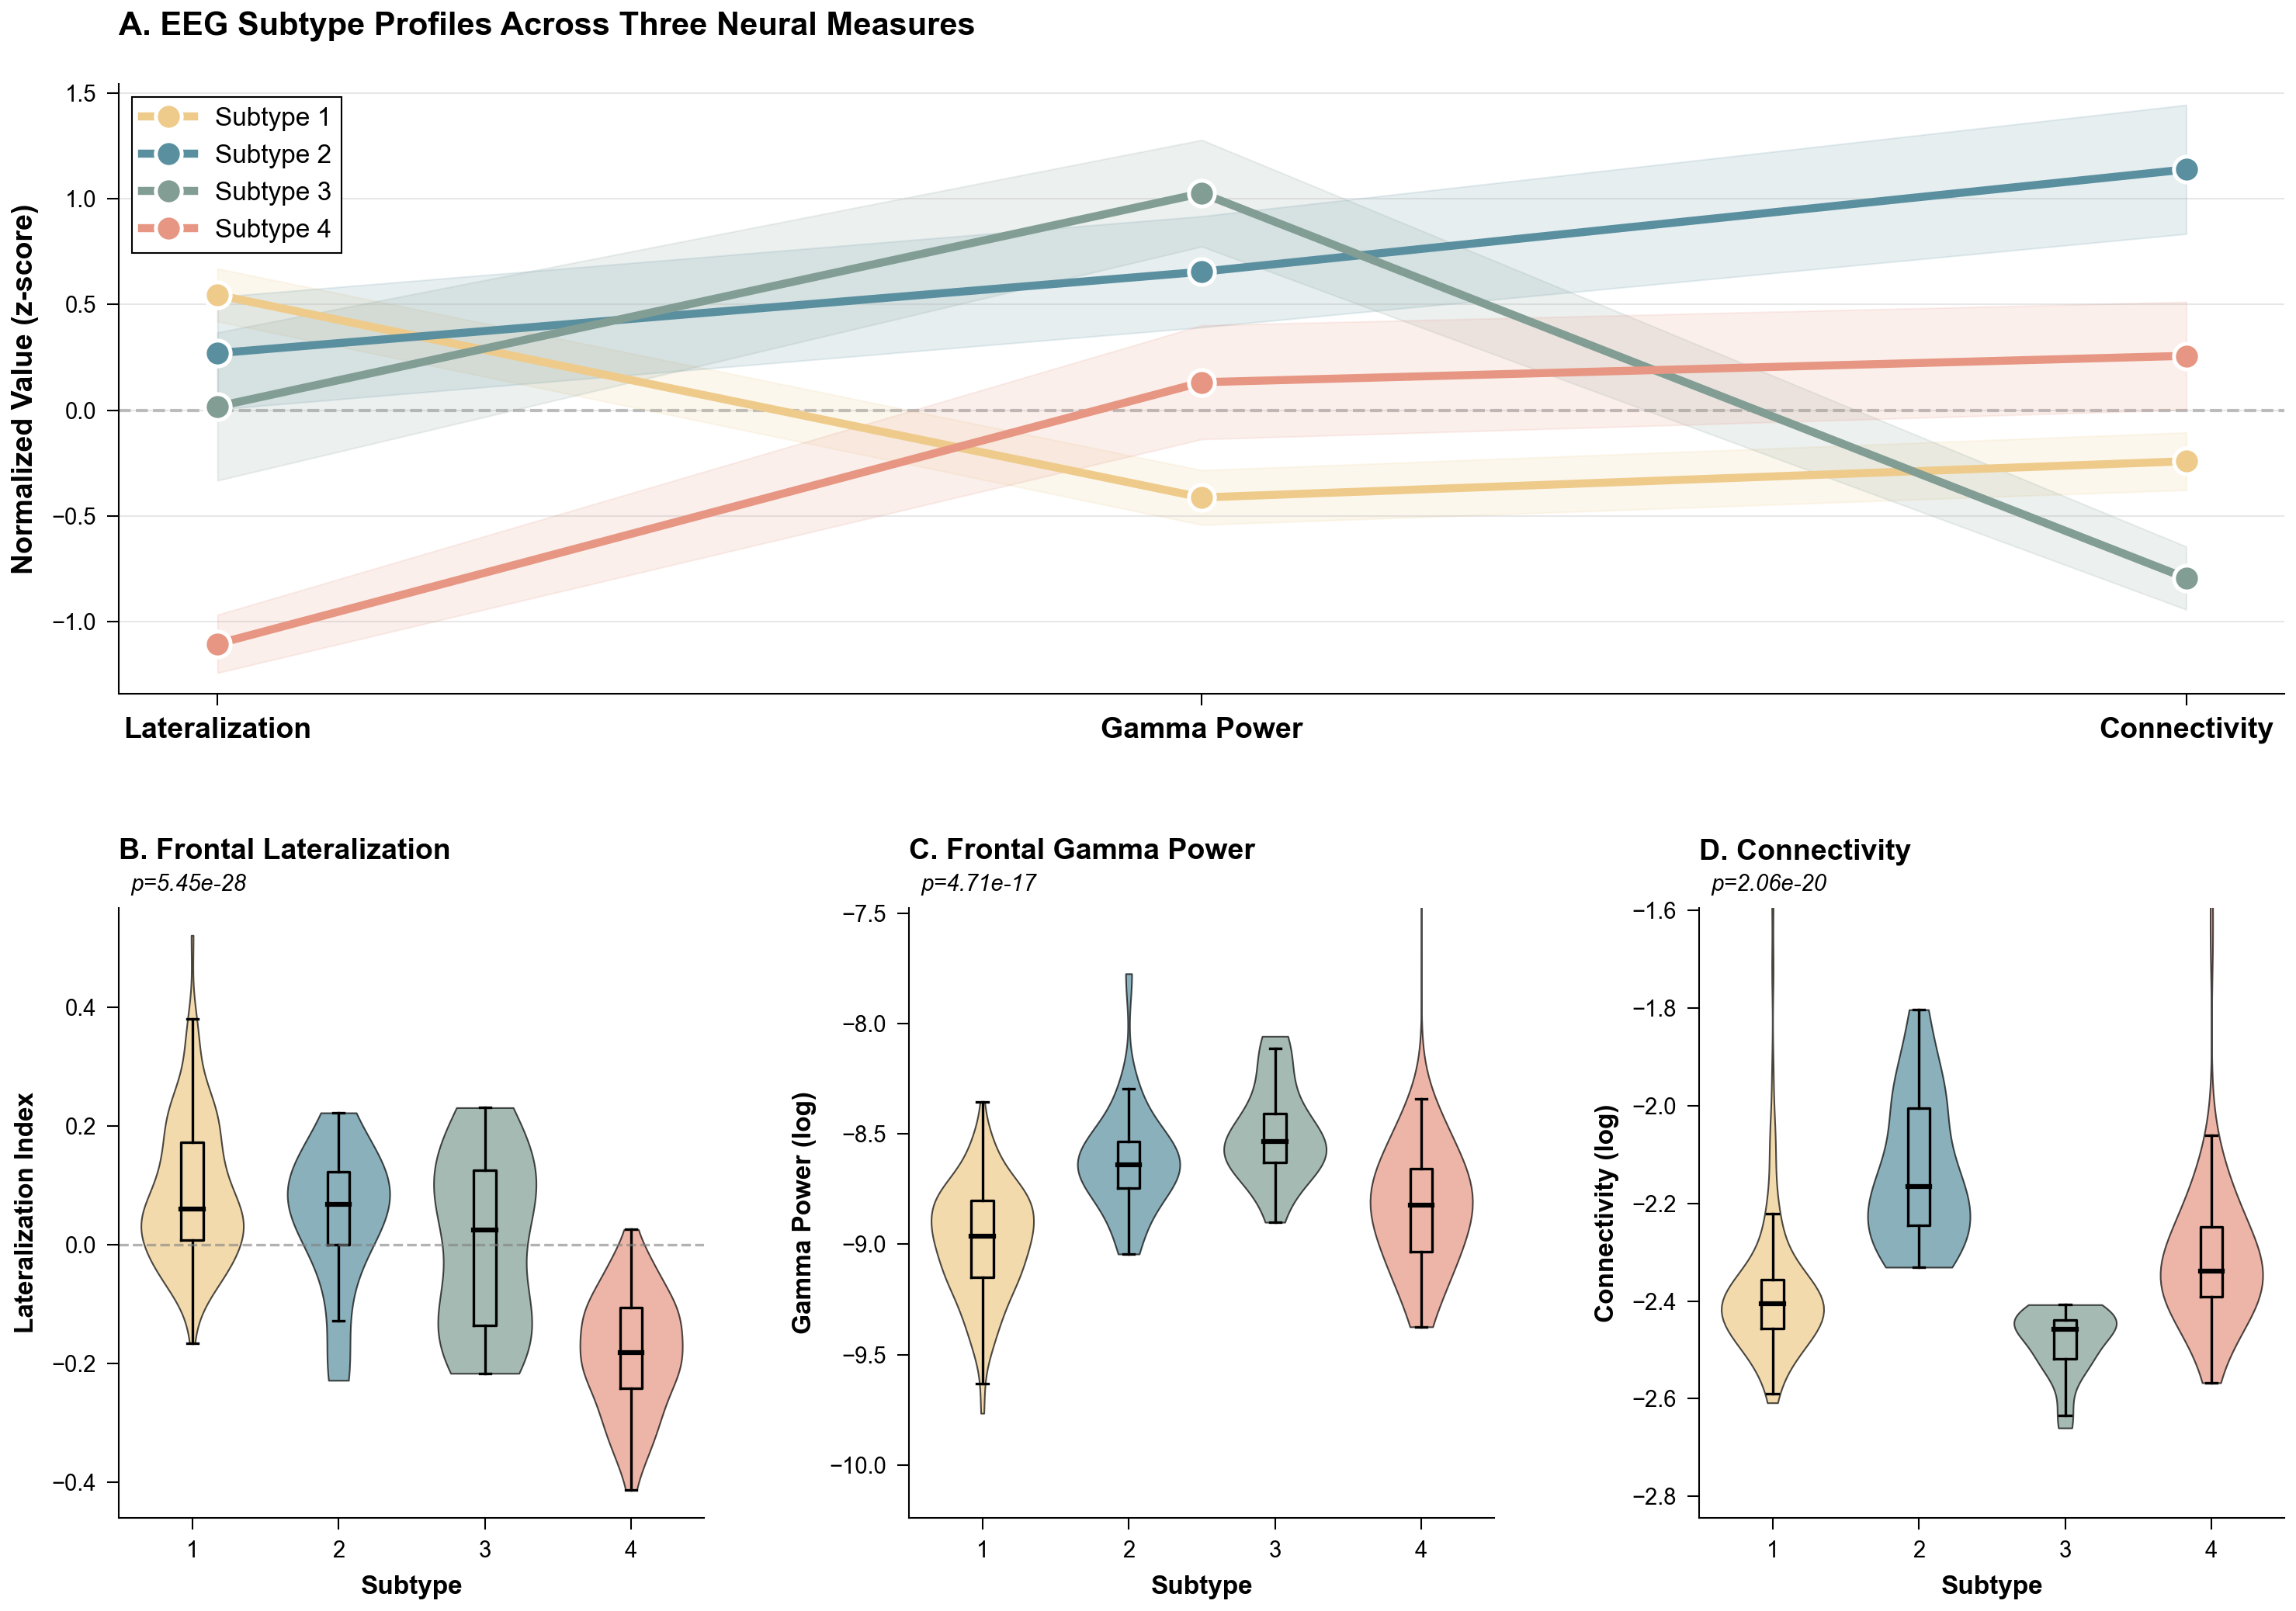


✓ Combined EEG Measures Panel generated
  Panel A: Parallel coordinates plot
  Panel B: Lateralization violin plot
  Panel C: Gamma power violin plot
  Panel D: Connectivity violin plot
  Files saved as: Combined_EEG_Measures_Panel.png/.pdf


In [42]:
print("="*70)
print("COMBINED EEG MEASURES PANEL")
print("="*70)

# Create figure with GridSpec for custom layout
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(2, 3, figure=fig, 
              height_ratios=[1, 1],
              width_ratios=[1, 1, 1],
              hspace=0.35, wspace=0.35)

# ============================================================================
# PANEL A: PARALLEL COORDINATES PLOT (Top, full width)
# ============================================================================
ax_parallel = fig.add_subplot(gs[0, :])

# Measure positions - SIMPLIFIED LABELS
measure_names_short = ['Lateralization', 'Gamma Power', 'Connectivity']
x_positions = np.arange(len(EEG_VARS))

# Plot each subtype's profile
for cluster in range(4):
    cluster_profile = profile_df[profile_df['cluster'] == cluster]
    means = cluster_profile['mean_z'].values
    ci_lower = cluster_profile['ci_lower'].values
    ci_upper = cluster_profile['ci_upper'].values
    
    # Plot line connecting measures
    ax_parallel.plot(x_positions, means, 'o-', 
            color=PALETTE_LIST[cluster], 
            linewidth=2.5, 
            markersize=8,
            label=f'Subtype {cluster + 1}',
            zorder=3,
            markeredgecolor='white',
            markeredgewidth=1.2)
    
    # Add 95% CI as shaded region
    ax_parallel.fill_between(x_positions, ci_lower, ci_upper,
                    color=PALETTE_LIST[cluster],
                    alpha=0.15,
                    zorder=1)

# Reference line at zero (population mean)
ax_parallel.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5, zorder=0)

# Styling
ax_parallel.set_xticks(x_positions)
ax_parallel.set_xticklabels(measure_names_short, fontsize=9, fontweight='bold')
ax_parallel.set_ylabel('Normalized Value (z-score)', fontsize=9, fontweight='bold')
ax_parallel.set_title('A. EEG Subtype Profiles Across Three Neural Measures',
             fontsize=10, fontweight='bold', pad=15, loc='left')

# Y-axis limits
all_means = profile_df['mean_z'].values
all_ci_lower = profile_df['ci_lower'].values
all_ci_upper = profile_df['ci_upper'].values
y_min = min(all_ci_lower.min(), all_means.min()) - 0.1
y_max = max(all_ci_upper.max(), all_means.max()) + 0.1
ax_parallel.set_ylim(y_min, y_max)

ax_parallel.spines['top'].set_visible(False)
ax_parallel.spines['right'].set_visible(False)
ax_parallel.grid(axis='y', alpha=0.3, linewidth=0.5, zorder=0)
ax_parallel.legend(fontsize=8, 
          loc='upper left',
          frameon=True,
          fancybox=False,
          edgecolor='black',
          framealpha=1)

print("✓ Panel A: Parallel coordinates plot created")

# ============================================================================
# PANEL B: LATERALIZATION VIOLIN PLOT (Bottom left)
# ============================================================================
ax_lat = fig.add_subplot(gs[1, 0])

# Violin plot
parts_lat = ax_lat.violinplot([lat_data[lat_data['hc_cluster'] == c]['l_index_frontal'].values 
                        for c in sorted(lat_data['hc_cluster'].unique())],
                       positions=range(4), widths=0.7, showmeans=False, showmedians=False)

# Color violin plots
for i, pc in enumerate(parts_lat['bodies']):
    pc.set_facecolor(PALETTE_LIST[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(0.5)

# Remove the blue bars
for partname in ('cbars', 'cmins', 'cmaxes'):
    if partname in parts_lat:
        vp = parts_lat[partname]
        vp.set_edgecolor('black')
        vp.set_linewidth(0)

# Add box plots for quartiles
bp_lat = ax_lat.boxplot([lat_data[lat_data['hc_cluster'] == c]['l_index_frontal'].values 
                 for c in sorted(lat_data['hc_cluster'].unique())],
                positions=range(4), widths=0.15, patch_artist=False,
                medianprops=dict(color='black', linewidth=1.5),
                boxprops=dict(color='black', linewidth=0.8),
                whiskerprops=dict(color='black', linewidth=0.8),
                capprops=dict(color='black', linewidth=0.8),
                showfliers=False)

# Add zero reference line
ax_lat.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# Formatting
ax_lat.set_xlabel('Subtype', fontsize=8, fontweight='bold')
ax_lat.set_ylabel('Lateralization Index', fontsize=8, fontweight='bold')
ax_lat.set_title('B. Frontal Lateralization',
             fontsize=9, fontweight='bold', loc='left', pad=15)
ax_lat.text(0.02, 1.02, f'p={overall_test["p_value"]:.2e}',
        transform=ax_lat.transAxes, fontsize=7, va='bottom', style='italic')
ax_lat.set_xticks(range(4))
ax_lat.set_xticklabels([f'{i+1}' for i in range(4)])
ax_lat.spines['top'].set_visible(False)
ax_lat.spines['right'].set_visible(False)

print("✓ Panel B: Lateralization violin plot created")

# ============================================================================
# PANEL C: GAMMA POWER VIOLIN PLOT (Bottom center)
# ============================================================================
ax_gamma = fig.add_subplot(gs[1, 1])

# Violin plot
parts_gamma = ax_gamma.violinplot([gamma_data[gamma_data['hc_cluster'] == c]['log_gamma_frontal_abs'].values 
                        for c in sorted(gamma_data['hc_cluster'].unique())],
                       positions=range(4), widths=0.7, showmeans=False, showmedians=False)

# Color violin plots
for i, pc in enumerate(parts_gamma['bodies']):
    pc.set_facecolor(PALETTE_LIST[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(0.5)

# Remove the blue bars
for partname in ('cbars', 'cmins', 'cmaxes'):
    if partname in parts_gamma:
        vp = parts_gamma[partname]
        vp.set_edgecolor('black')
        vp.set_linewidth(0)

# Add box plots for quartiles
bp_gamma = ax_gamma.boxplot([gamma_data[gamma_data['hc_cluster'] == c]['log_gamma_frontal_abs'].values 
                 for c in sorted(gamma_data['hc_cluster'].unique())],
                positions=range(4), widths=0.15, patch_artist=False,
                medianprops=dict(color='black', linewidth=1.5),
                boxprops=dict(color='black', linewidth=0.8),
                whiskerprops=dict(color='black', linewidth=0.8),
                capprops=dict(color='black', linewidth=0.8),
                showfliers=False)

# Set y-axis limits
y_min_pct_g = gamma_data['log_gamma_frontal_abs'].quantile(0.025)
y_max_pct_g = gamma_data['log_gamma_frontal_abs'].quantile(0.975)
y_range_g = y_max_pct_g - y_min_pct_g
ax_gamma.set_ylim(y_min_pct_g - 0.7 * y_range_g, y_max_pct_g + 0.7 * y_range_g)

# Formatting
ax_gamma.set_xlabel('Subtype', fontsize=8, fontweight='bold')
ax_gamma.set_ylabel('Gamma Power (log)', fontsize=8, fontweight='bold')
ax_gamma.set_title('C. Frontal Gamma Power',
             fontsize=9, fontweight='bold', loc='left', pad=15)
ax_gamma.text(0.02, 1.02, f'p={gamma_test["p_value"]:.2e}',
        transform=ax_gamma.transAxes, fontsize=7, va='bottom', style='italic')
ax_gamma.set_xticks(range(4))
ax_gamma.set_xticklabels([f'{i+1}' for i in range(4)])
ax_gamma.spines['top'].set_visible(False)
ax_gamma.spines['right'].set_visible(False)

print("✓ Panel C: Gamma power violin plot created")

# ============================================================================
# PANEL D: CONNECTIVITY VIOLIN PLOT (Bottom right)
# ============================================================================
ax_conn = fig.add_subplot(gs[1, 2])

# Violin plot
parts_conn = ax_conn.violinplot([conn_data[conn_data['hc_cluster'] == c]['log_con'].values 
                        for c in sorted(conn_data['hc_cluster'].unique())],
                       positions=range(4), widths=0.7, showmeans=False, showmedians=False)

# Color violin plots
for i, pc in enumerate(parts_conn['bodies']):
    pc.set_facecolor(PALETTE_LIST[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(0.5)

# Remove the blue bars
for partname in ('cbars', 'cmins', 'cmaxes'):
    if partname in parts_conn:
        vp = parts_conn[partname]
        vp.set_edgecolor('black')
        vp.set_linewidth(0)

# Add box plots for quartiles
bp_conn = ax_conn.boxplot([conn_data[conn_data['hc_cluster'] == c]['log_con'].values 
                 for c in sorted(conn_data['hc_cluster'].unique())],
                positions=range(4), widths=0.15, patch_artist=False,
                medianprops=dict(color='black', linewidth=1.5),
                boxprops=dict(color='black', linewidth=0.8),
                whiskerprops=dict(color='black', linewidth=0.8),
                capprops=dict(color='black', linewidth=0.8),
                showfliers=False)

# Set y-axis limits
y_min_pct_c = conn_data['log_con'].quantile(0.025)
y_max_pct_c = conn_data['log_con'].quantile(0.975)
y_range_c = y_max_pct_c - y_min_pct_c
ax_conn.set_ylim(y_min_pct_c - 0.4 * y_range_c, y_max_pct_c + 0.4 * y_range_c)

# Formatting
ax_conn.set_xlabel('Subtype', fontsize=8, fontweight='bold')
ax_conn.set_ylabel('Connectivity (log)', fontsize=8, fontweight='bold')
ax_conn.set_title('D. Connectivity',
             fontsize=9, fontweight='bold', loc='left', pad=15)
ax_conn.text(0.02, 1.02, f'p={conn_test["p_value"]:.2e}',
        transform=ax_conn.transAxes, fontsize=7, va='bottom', style='italic')
ax_conn.set_xticks(range(4))
ax_conn.set_xticklabels([f'{i+1}' for i in range(4)])
ax_conn.spines['top'].set_visible(False)
ax_conn.spines['right'].set_visible(False)

print("✓ Panel D: Connectivity violin plot created")

# Save combined figure
plt.savefig(FIGURE_OUTPUT / 'Combined_EEG_Measures_Panel.png', 
            dpi=300, bbox_inches='tight', pad_inches=0.3)
plt.savefig(FIGURE_OUTPUT / 'Combined_EEG_Measures_Panel.pdf', 
            bbox_inches='tight', pad_inches=0.3)
plt.show()

print("\n✓ Combined EEG Measures Panel generated")
print(f"  Panel A: Parallel coordinates plot")
print(f"  Panel B: Lateralization violin plot")
print(f"  Panel C: Gamma power violin plot")
print(f"  Panel D: Connectivity violin plot")
print(f"  Files saved as: Combined_EEG_Measures_Panel.png/.pdf")

### Panel 1A: Dendrogram & Cluster Sizes

  Total subjects: 257
  Variables: ['l_index_frontal', 'log_gamma_frontal_abs', 'log_con']
  Source: combined_data_EEG.csv (original MICE-imputed, normalized)


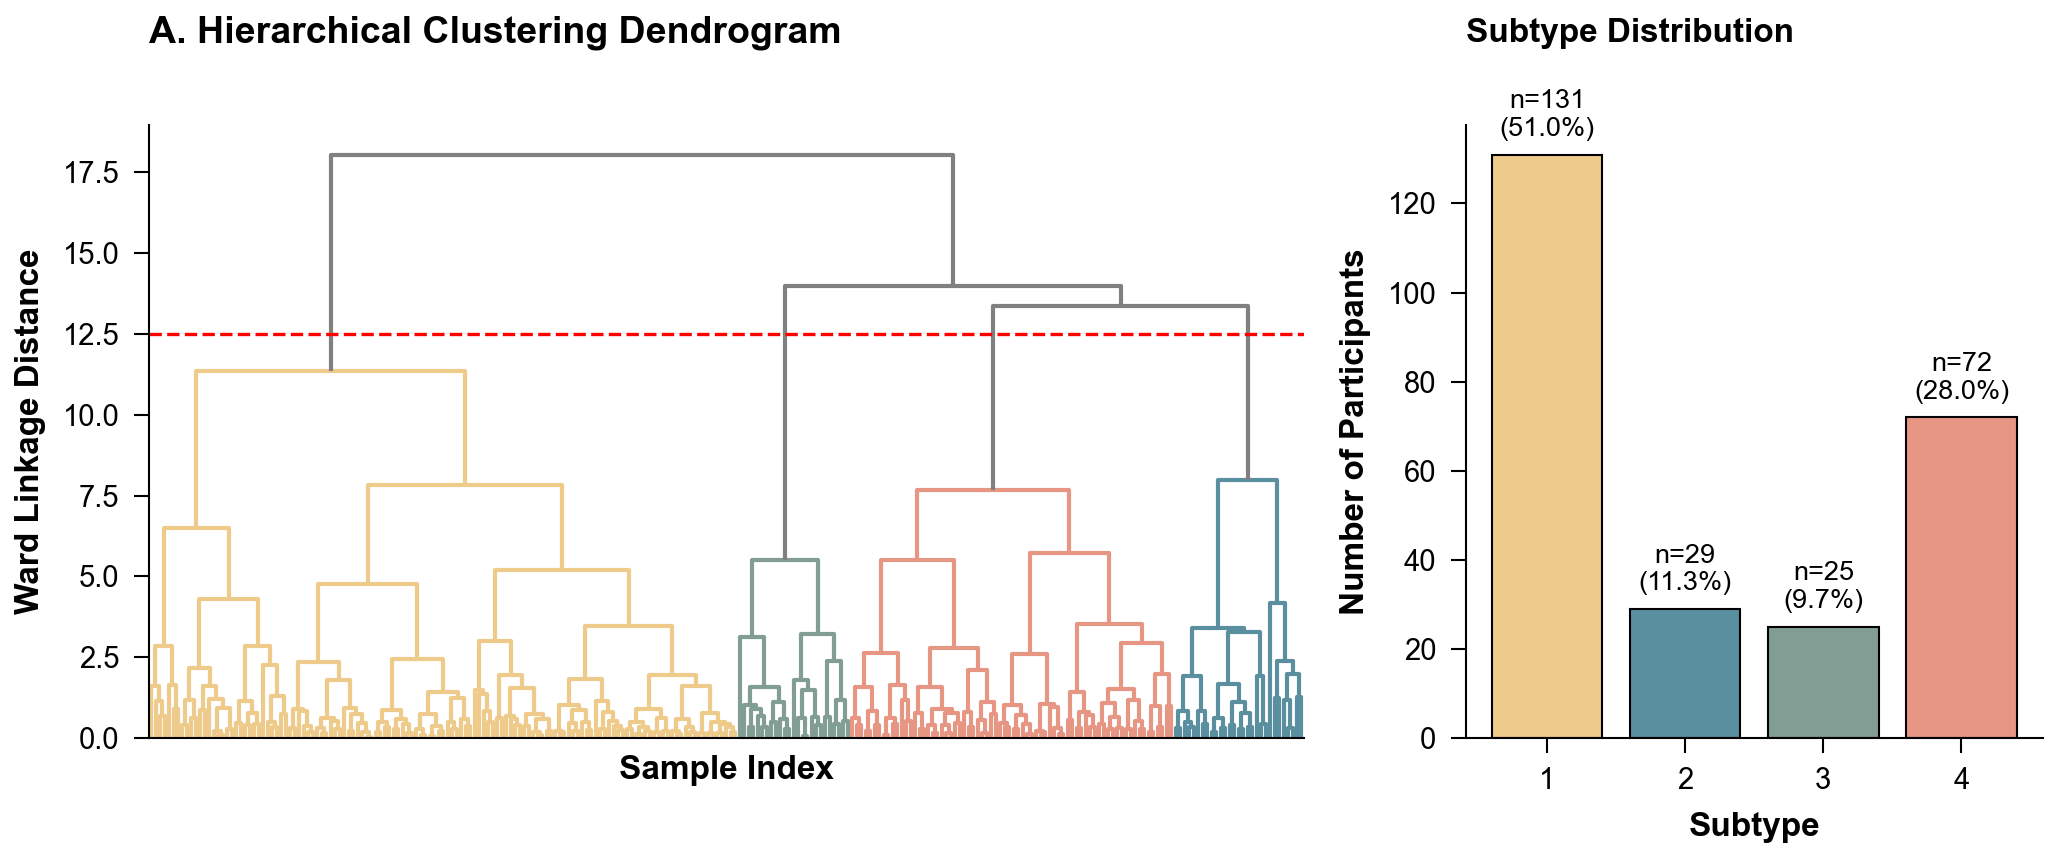

✓ Figure 1A generated


In [29]:
# ====================================================================

print(f"  Total subjects: {len(normalized_eeg)}")
print(f"  Variables: {EEG_VARS}")
print(f"  Source: combined_data_EEG.csv (original MICE-imputed, normalized)")

# Get normalized EEG data from merged data
normalized_data = normalized_eeg.copy()

# Convert to numpy array for clustering
X_scaled = normalized_data.values

# Compute linkage
Z = linkage(X_scaled, method='ward', metric='euclidean')

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), 
                                gridspec_kw={'width_ratios': [2, 1]})

# Panel 1A: Dendrogram
# Set custom colors for dendrogram branches
from scipy.cluster.hierarchy import set_link_color_palette
# Reorder colors for dendrogram: mustard, gray, salmon, blue (indices 0, 2, 3, 1)
palette_dendrogram = [PALETTE_LIST[0], PALETTE_LIST[2], PALETTE_LIST[3], PALETTE_LIST[1]]
palette_hex = ['#%02x%02x%02x' % (int(r*255), int(g*255), int(b*255)) for r, g, b in palette_dendrogram]
set_link_color_palette(palette_hex)
color_threshold=12.5
dendrogram(Z, ax=ax1, color_threshold=color_threshold, above_threshold_color='gray', no_labels=True)
ax1.axhline(y=color_threshold, color='red', linestyle='--', linewidth=0.8, label='4-cluster cutoff')
ax1.set_xlabel('Sample Index', fontsize=8, fontweight='bold')
ax1.set_ylabel('Ward Linkage Distance', fontsize=8, fontweight='bold')
ax1.set_title('A. Hierarchical Clustering Dendrogram', 
              fontsize=9, fontweight='bold', loc='left', pad=20) 
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Reset color palette to default after use
set_link_color_palette(None)

# Panel 1A inset: Cluster sizes
cluster_counts = merged_data['subtype'].value_counts().sort_index()
bars = ax2.bar(range(len(cluster_counts)), cluster_counts.values, 
               color=PALETTE_LIST, edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Subtype', fontsize=8, fontweight='bold')
ax2.set_ylabel('Number of Participants', fontsize=8, fontweight='bold')
ax2.set_title('Subtype Distribution', fontsize=8, fontweight='bold', loc='left', pad=20)
ax2.set_xticks(range(len(cluster_counts)))
ax2.set_xticklabels([f'{i+1}' for i in range(len(cluster_counts))])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Add n and % labels on bars
for i, (bar, count) in enumerate(zip(bars, cluster_counts.values)):
    height = bar.get_height()
    pct = (count / n_total) * 100
    ax2.text(bar.get_x() + bar.get_width()/2, height + 3,
             f'n={count}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=6.5)

plt.tight_layout()
plt.savefig(FIGURE_OUTPUT / 'Figure1A_Dendrogram_Sizes.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURE_OUTPUT / 'Figure1A_Dendrogram_Sizes.pdf', bbox_inches='tight')
plt.show()

print("✓ Figure 1A generated")

### Panel 1B: Frontal Lateralization by Subtype

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


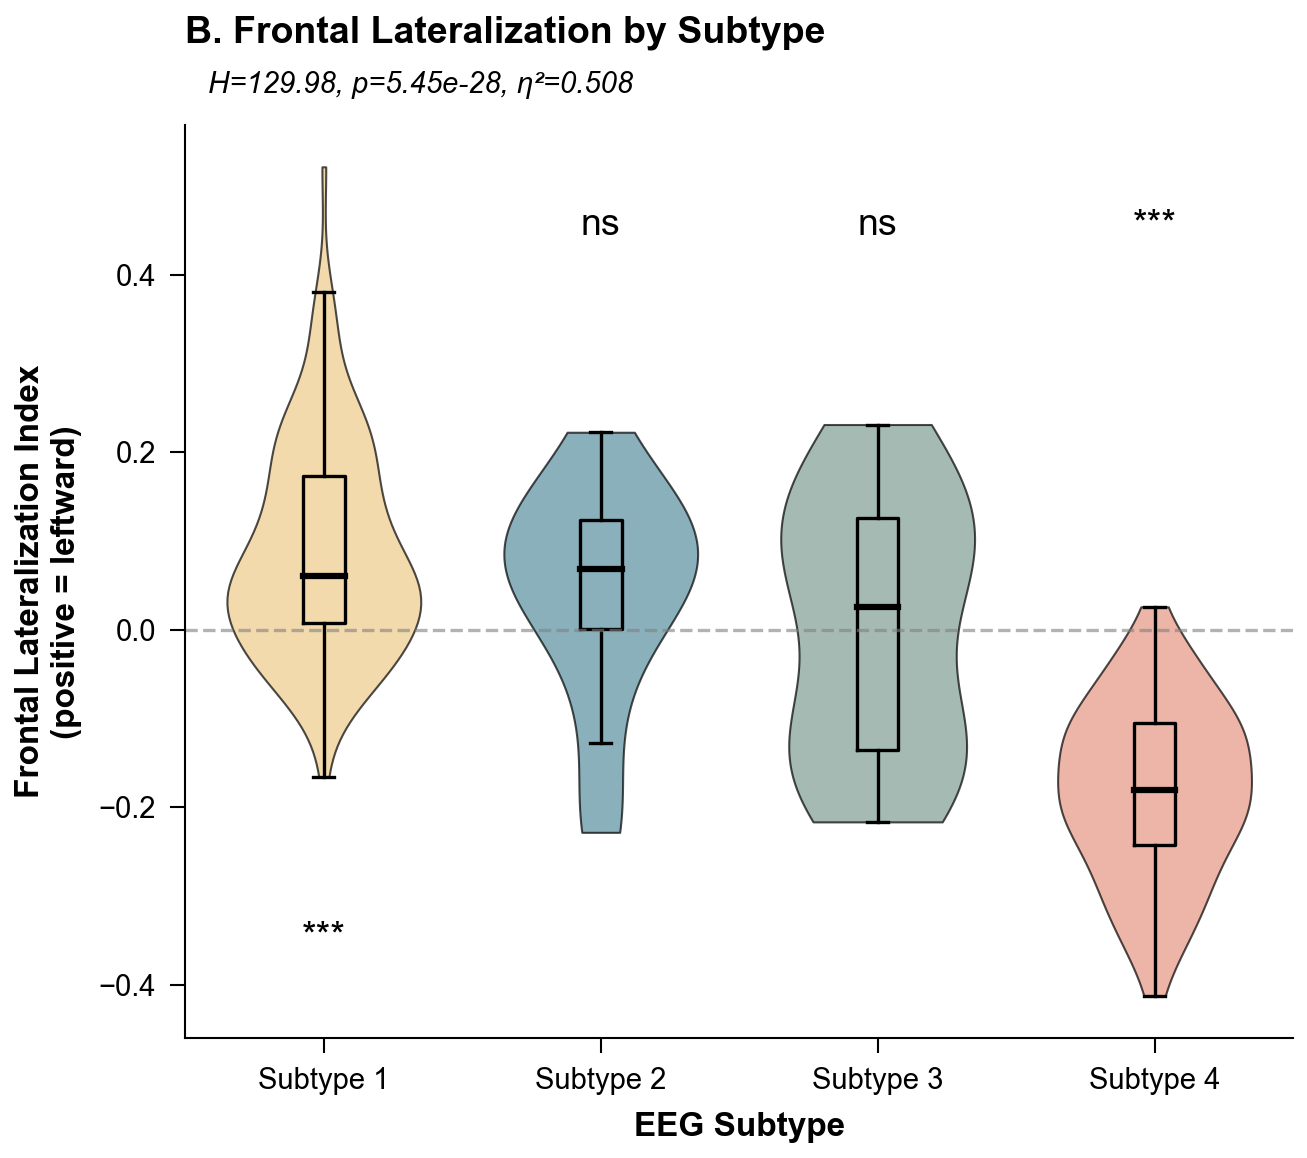

✓ Figure 1B generated with statistics


In [30]:
#FIGURE 1B: Laterlization

# Prepare lateralization data
lat_data = merged_data[['hc_cluster', 'subtype', 'l_index_frontal']].dropna()

# Overall test
overall_test = comprehensive_test_continuous(lat_data, 'l_index_frontal')

# One-sample t-tests for each cluster
cluster_tests = {}
for cluster in sorted(lat_data['hc_cluster'].unique()):
    cluster_tests[int(cluster)] = one_sample_ttest_lateralization(lat_data, cluster)

# Create figure
fig, ax = plt.subplots(figsize=(4.5, 4))

# Violin plot with individual points
parts = ax.violinplot([lat_data[lat_data['hc_cluster'] == c]['l_index_frontal'].values 
                        for c in sorted(lat_data['hc_cluster'].unique())],
                       positions=range(4), widths=0.7, showmeans=False, showmedians=False)

# Color violin plots and remove ALL blue elements
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETTE_LIST[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(0.5)

# Remove the blue bars, mins, and maxes from violinplot
for partname in ('cbars', 'cmins', 'cmaxes'):
    if partname in parts:
        vp = parts[partname]
        vp.set_edgecolor('black')
        vp.set_linewidth(0)  # Hide these completely

# Add box plots for quartiles
bp = ax.boxplot([lat_data[lat_data['hc_cluster'] == c]['l_index_frontal'].values 
                 for c in sorted(lat_data['hc_cluster'].unique())],
                positions=range(4), widths=0.15, patch_artist=False,
                medianprops=dict(color='black', linewidth=1.5),
                boxprops=dict(color='black', linewidth=0.8),
                whiskerprops=dict(color='black', linewidth=0.8),
                capprops=dict(color='black', linewidth=0.8),
                flierprops=dict(color='black'),
                showfliers=False)

# Add zero reference line
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# Add significance annotations for one-sample tests
# Positioned within the plot area, above each violin (except first subtype at bottom)
y_max = lat_data['l_index_frontal'].max()
y_min = lat_data['l_index_frontal'].min()
y_range = y_max - y_min

for i, cluster in enumerate(sorted(lat_data['hc_cluster'].unique())):
    result = cluster_tests[int(cluster)]
    if result['p'] < 0.001:
        sig_text = '***'
    elif result['p'] < 0.01:
        sig_text = '**'
    elif result['p'] < 0.05:
        sig_text = '*'
    else:
        sig_text = 'ns'
    
    # First subtype (i==0) at bottom, others at top
    if i == 0:
        y_annotation = y_min + (y_range * 0.05)
        va_align = 'bottom'
    else:
        y_annotation = y_max - (y_range * 0.05)
        va_align = 'top'
    
    ax.text(i, y_annotation, sig_text, ha='center', va=va_align,
            fontsize=9, color='black')

# Formatting
ax.set_xlabel('EEG Subtype', fontsize=8, fontweight='bold')
ax.set_ylabel('Frontal Lateralization Index\n(positive = leftward)', fontsize=8, fontweight='bold')
ax.set_title('B. Frontal Lateralization by Subtype',
             fontsize=9, fontweight='bold', loc='left', pad=20)
# Add statistics as subtitle - positioned high, just below title
ax.text(0.02, 1.06, f'H={overall_test["statistic"]:.2f}, p={overall_test["p_value"]:.2e}, η²={overall_test["effect_size"]:.3f}',
        transform=ax.transAxes, fontsize=7, va='top', style='italic')
        
ax.set_xticks(range(4))
ax.set_xticklabels([f'Subtype {i+1}' for i in range(4)])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', fontsize=6)

plt.tight_layout()
plt.savefig(FIGURE_OUTPUT / 'Figure1B_Lateralization.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURE_OUTPUT / 'Figure1B_Lateralization.pdf', bbox_inches='tight')
plt.show()

print("✓ Figure 1B generated with statistics")

### Panel 1C: Gamma Power by Subtype

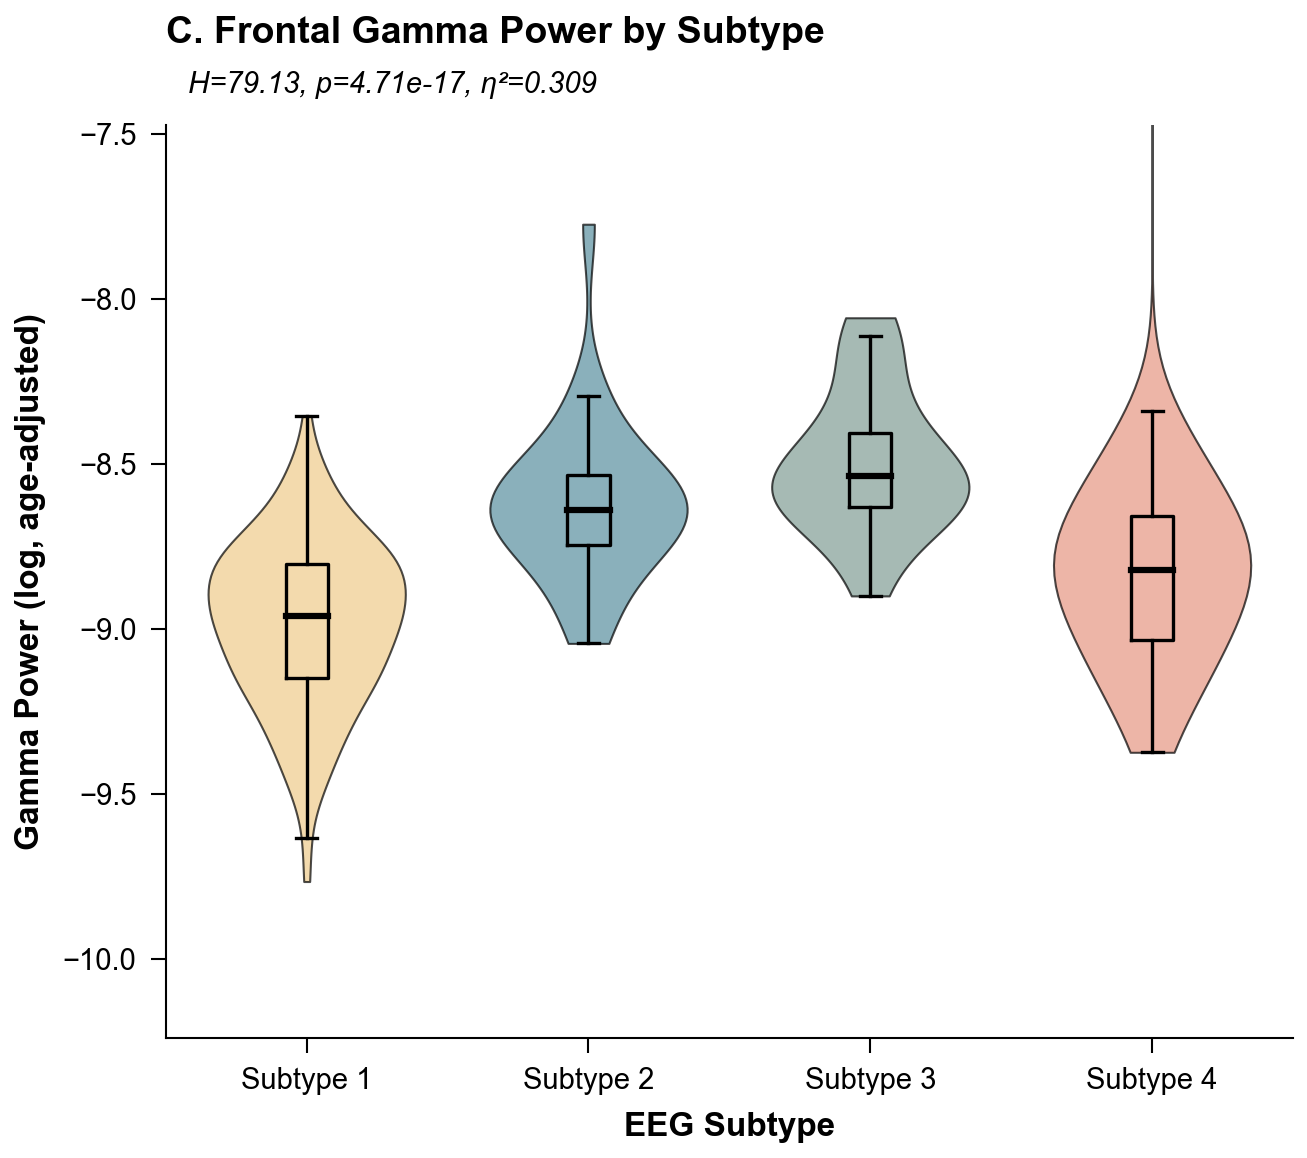


FIGURE 1C: GAMMA POWER STATISTICS

Overall Kruskal-Wallis Test:
  H = 79.13
  p = 0.000000
  η² = 0.309
✓ Figure 1C generated with statistics
  n = 257


,0,1,2,3
0,1.0000,0.0000,0.0,0.0018
1,0.0000,1.0000,1.0,0.0071
2,0.0000,1.0000,1.0,0.0000
3,0.0018,0.0071,0.0,1.0000



Post-hoc Dunn's test (Bonferroni corrected):


In [31]:
# Prepare gamma power data
gamma_data = merged_data[['hc_cluster', 'subtype', 'log_gamma_frontal_abs']].dropna()

# Overall test
gamma_test = comprehensive_test_continuous(gamma_data, 'log_gamma_frontal_abs')

# Post-hoc Dunn's test
dunn_gamma = sp.posthoc_dunn(gamma_data, val_col='log_gamma_frontal_abs', 
                              group_col='hc_cluster', p_adjust='bonferroni')

# Create figure
fig, ax = plt.subplots(figsize=(4.5, 4))

# Violin plot
parts = ax.violinplot([gamma_data[gamma_data['hc_cluster'] == c]['log_gamma_frontal_abs'].values 
                        for c in sorted(gamma_data['hc_cluster'].unique())],
                       positions=range(4), widths=0.7, showmeans=False, showmedians=False)

# Color violin plots and remove ALL blue elements
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETTE_LIST[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(0.5)

# Remove the blue bars, mins, and maxes from violinplot
for partname in ('cbars', 'cmins', 'cmaxes'):
    if partname in parts:
        vp = parts[partname]
        vp.set_edgecolor('black')
        vp.set_linewidth(0)

# Add box plots for quartiles
bp = ax.boxplot([gamma_data[gamma_data['hc_cluster'] == c]['log_gamma_frontal_abs'].values 
                 for c in sorted(gamma_data['hc_cluster'].unique())],
                positions=range(4), widths=0.15, patch_artist=False,
                medianprops=dict(color='black', linewidth=1.5),
                boxprops=dict(color='black', linewidth=0.8),
                whiskerprops=dict(color='black', linewidth=0.8),
                capprops=dict(color='black', linewidth=0.8),
                flierprops=dict(color='black'),
                showfliers=False)

# Set y-axis limits to handle outliers (focus on main distribution)
# Calculate percentile-based limits for cleaner visualization
y_min_pct = gamma_data['log_gamma_frontal_abs'].quantile(0.025)
y_max_pct = gamma_data['log_gamma_frontal_abs'].quantile(0.975)
y_range = y_max_pct - y_min_pct
ax.set_ylim(y_min_pct - 0.7 * y_range, y_max_pct + 0.7 * y_range)

# Formatting
ax.set_xlabel('EEG Subtype', fontsize=8, fontweight='bold')
ax.set_ylabel('Gamma Power (log, age-adjusted)', fontsize=8, fontweight='bold')
ax.set_title('C. Frontal Gamma Power by Subtype',
             fontsize=9, fontweight='bold', loc='left', pad=20)
# Add statistics as subtitle
ax.text(0.02, 1.06, f'H={gamma_test["statistic"]:.2f}, p={gamma_test["p_value"]:.2e}, η²={gamma_test["effect_size"]:.3f}',
        transform=ax.transAxes, fontsize=7, va='top', style='italic')
        
ax.set_xticks(range(4))
ax.set_xticklabels([f'Subtype {i+1}' for i in range(4)])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_OUTPUT / 'Figure1C_GammaPower.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURE_OUTPUT / 'Figure1C_GammaPower.pdf', bbox_inches='tight')
plt.show()

# Print detailed statistics
print("\n" + "="*70)
print("FIGURE 1C: GAMMA POWER STATISTICS")
print("="*70)
print(f"\nOverall Kruskal-Wallis Test:")
print(f"  H = {gamma_test['statistic']:.2f}")
print(f"  p = {gamma_test['p_value']:.6f}")

print(f"  η² = {gamma_test['effect_size']:.3f}")
print("✓ Figure 1C generated with statistics")

print(f"  n = {gamma_test['n']}")

display(dunn_gamma.round(4))
print("\nPost-hoc Dunn's test (Bonferroni corrected):")

### Panel 1D: Connectivity by Subtype

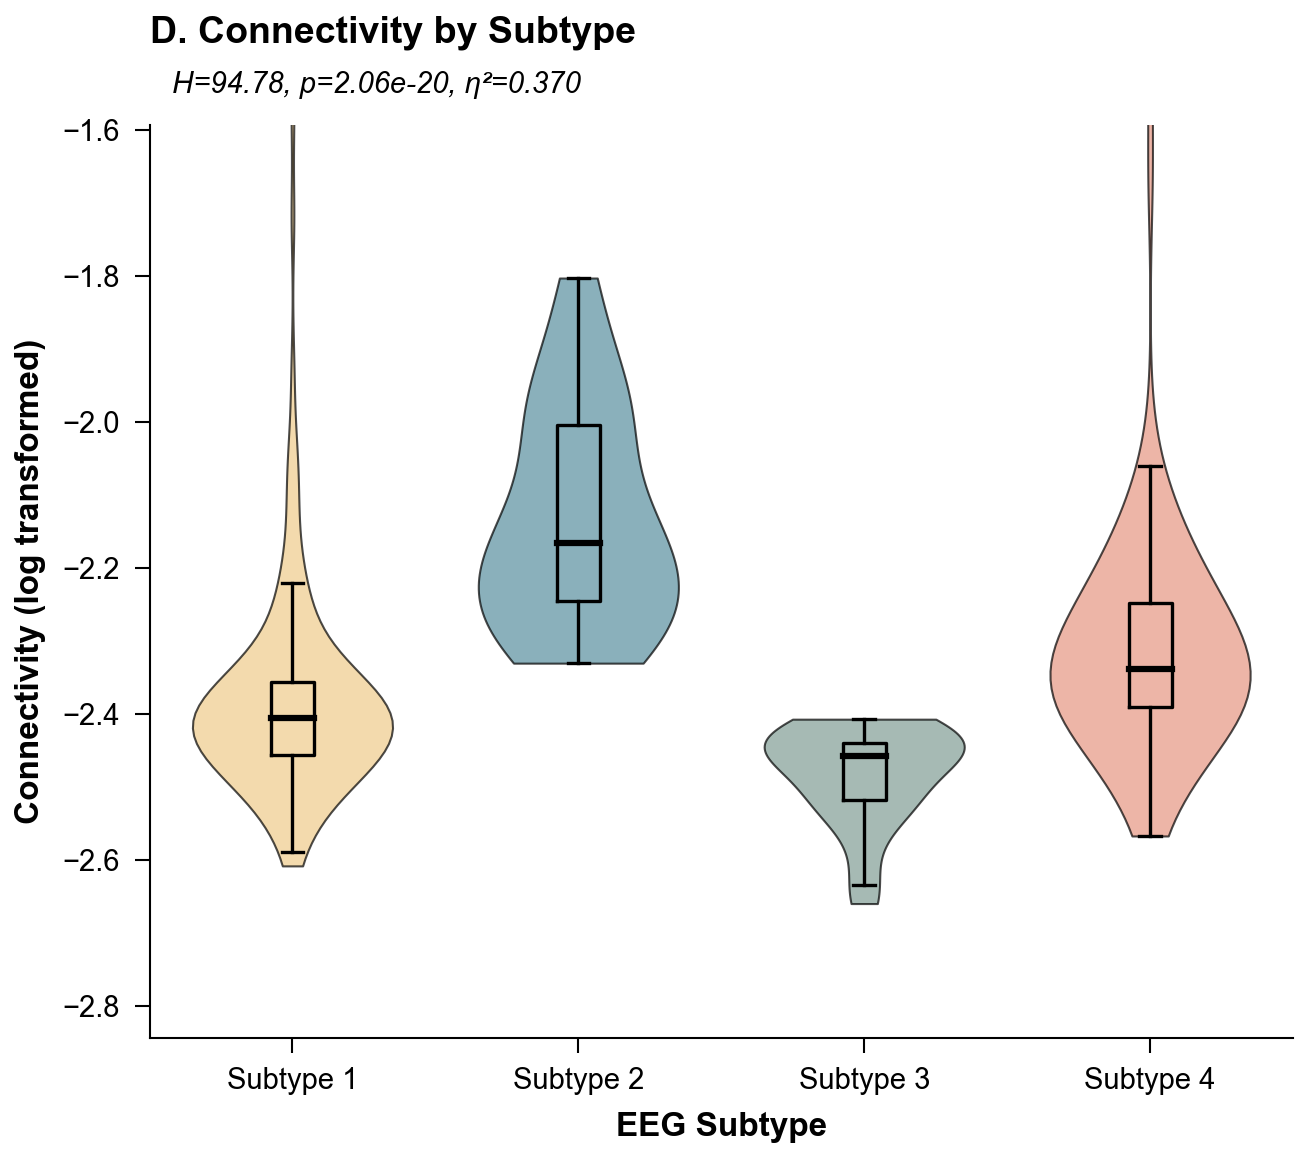


FIGURE 1D: CONNECTIVITY STATISTICS

Overall Kruskal-Wallis Test:
  H = 94.78
  p = 0.000000
  η² = 0.370
✓ Figure 1D generated with statistics
  n = 257


,0,1,2,3
0,1.0000,0.0000,0.0014,0.0000
1,0.0000,1.0000,0.0000,0.0006
2,0.0014,0.0000,1.0000,0.0000
3,0.0000,0.0006,0.0000,1.0000



Post-hoc Dunn's test (Bonferroni corrected):


In [32]:
"""
═══════════════════════════════════════════════════════════════════════════════
FIGURE 1D: CONNECTIVITY BY SUBTYPE
═══════════════════════════════════════════════════════════════════════════════
"""

# Prepare connectivity data
conn_data = merged_data[['hc_cluster', 'subtype', 'log_con']].dropna()

# Overall test
conn_test = comprehensive_test_continuous(conn_data, 'log_con')

# Post-hoc Dunn's test
dunn_conn = sp.posthoc_dunn(conn_data, val_col='log_con', 
                             group_col='hc_cluster', p_adjust='bonferroni')

# Create figure
fig, ax = plt.subplots(figsize=(4.5, 4))

# Violin plot
parts = ax.violinplot([conn_data[conn_data['hc_cluster'] == c]['log_con'].values 
                        for c in sorted(conn_data['hc_cluster'].unique())],
                       positions=range(4), widths=0.7, showmeans=False, showmedians=False)

# Color violin plots and remove ALL blue elements
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETTE_LIST[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(0.5)

# Remove the blue bars, mins, and maxes from violinplot
for partname in ('cbars', 'cmins', 'cmaxes'):
    if partname in parts:
        vp = parts[partname]
        vp.set_edgecolor('black')
        vp.set_linewidth(0)

# Add box plots for quartiles
bp = ax.boxplot([conn_data[conn_data['hc_cluster'] == c]['log_con'].values 
                 for c in sorted(conn_data['hc_cluster'].unique())],
                positions=range(4), widths=0.15, patch_artist=False,
                medianprops=dict(color='black', linewidth=1.5),
                boxprops=dict(color='black', linewidth=0.8),
                whiskerprops=dict(color='black', linewidth=0.8),
                capprops=dict(color='black', linewidth=0.8),
                flierprops=dict(color='black'),
                showfliers=False)

# Set y-axis limits to handle outliers (focus on main distribution)
# Calculate percentile-based limits for cleaner visualization
y_min_pct = conn_data['log_con'].quantile(0.025)
y_max_pct = conn_data['log_con'].quantile(0.975)
y_range = y_max_pct - y_min_pct
ax.set_ylim(y_min_pct - 0.4 * y_range, y_max_pct + 0.4 * y_range)

# Formatting
ax.set_xlabel('EEG Subtype', fontsize=8, fontweight='bold')
ax.set_ylabel('Connectivity (log transformed)', fontsize=8, fontweight='bold')
ax.set_title('D. Connectivity by Subtype',
             fontsize=9, fontweight='bold', loc='left', pad=20)
# Add statistics as subtitle
ax.text(0.02, 1.06, f'H={conn_test["statistic"]:.2f}, p={conn_test["p_value"]:.2e}, η²={conn_test["effect_size"]:.3f}',
        transform=ax.transAxes, fontsize=7, va='top', style='italic')
        
ax.set_xticks(range(4))
ax.set_xticklabels([f'Subtype {i+1}' for i in range(4)])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_OUTPUT / 'Figure1D_Connectivity.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURE_OUTPUT / 'Figure1D_Connectivity.pdf', bbox_inches='tight')
plt.show()

# Print detailed statistics
print("\n" + "="*70)
print("FIGURE 1D: CONNECTIVITY STATISTICS")
print("="*70)
print(f"\nOverall Kruskal-Wallis Test:")
print(f"  H = {conn_test['statistic']:.2f}")
print(f"  p = {conn_test['p_value']:.6f}")

print(f"  η² = {conn_test['effect_size']:.3f}")
print("✓ Figure 1D generated with statistics")

print(f"  n = {conn_test['n']}")

display(dunn_conn.round(4))
print("\nPost-hoc Dunn's test (Bonferroni corrected):")

### Panel 1E: Demographics by Subtype

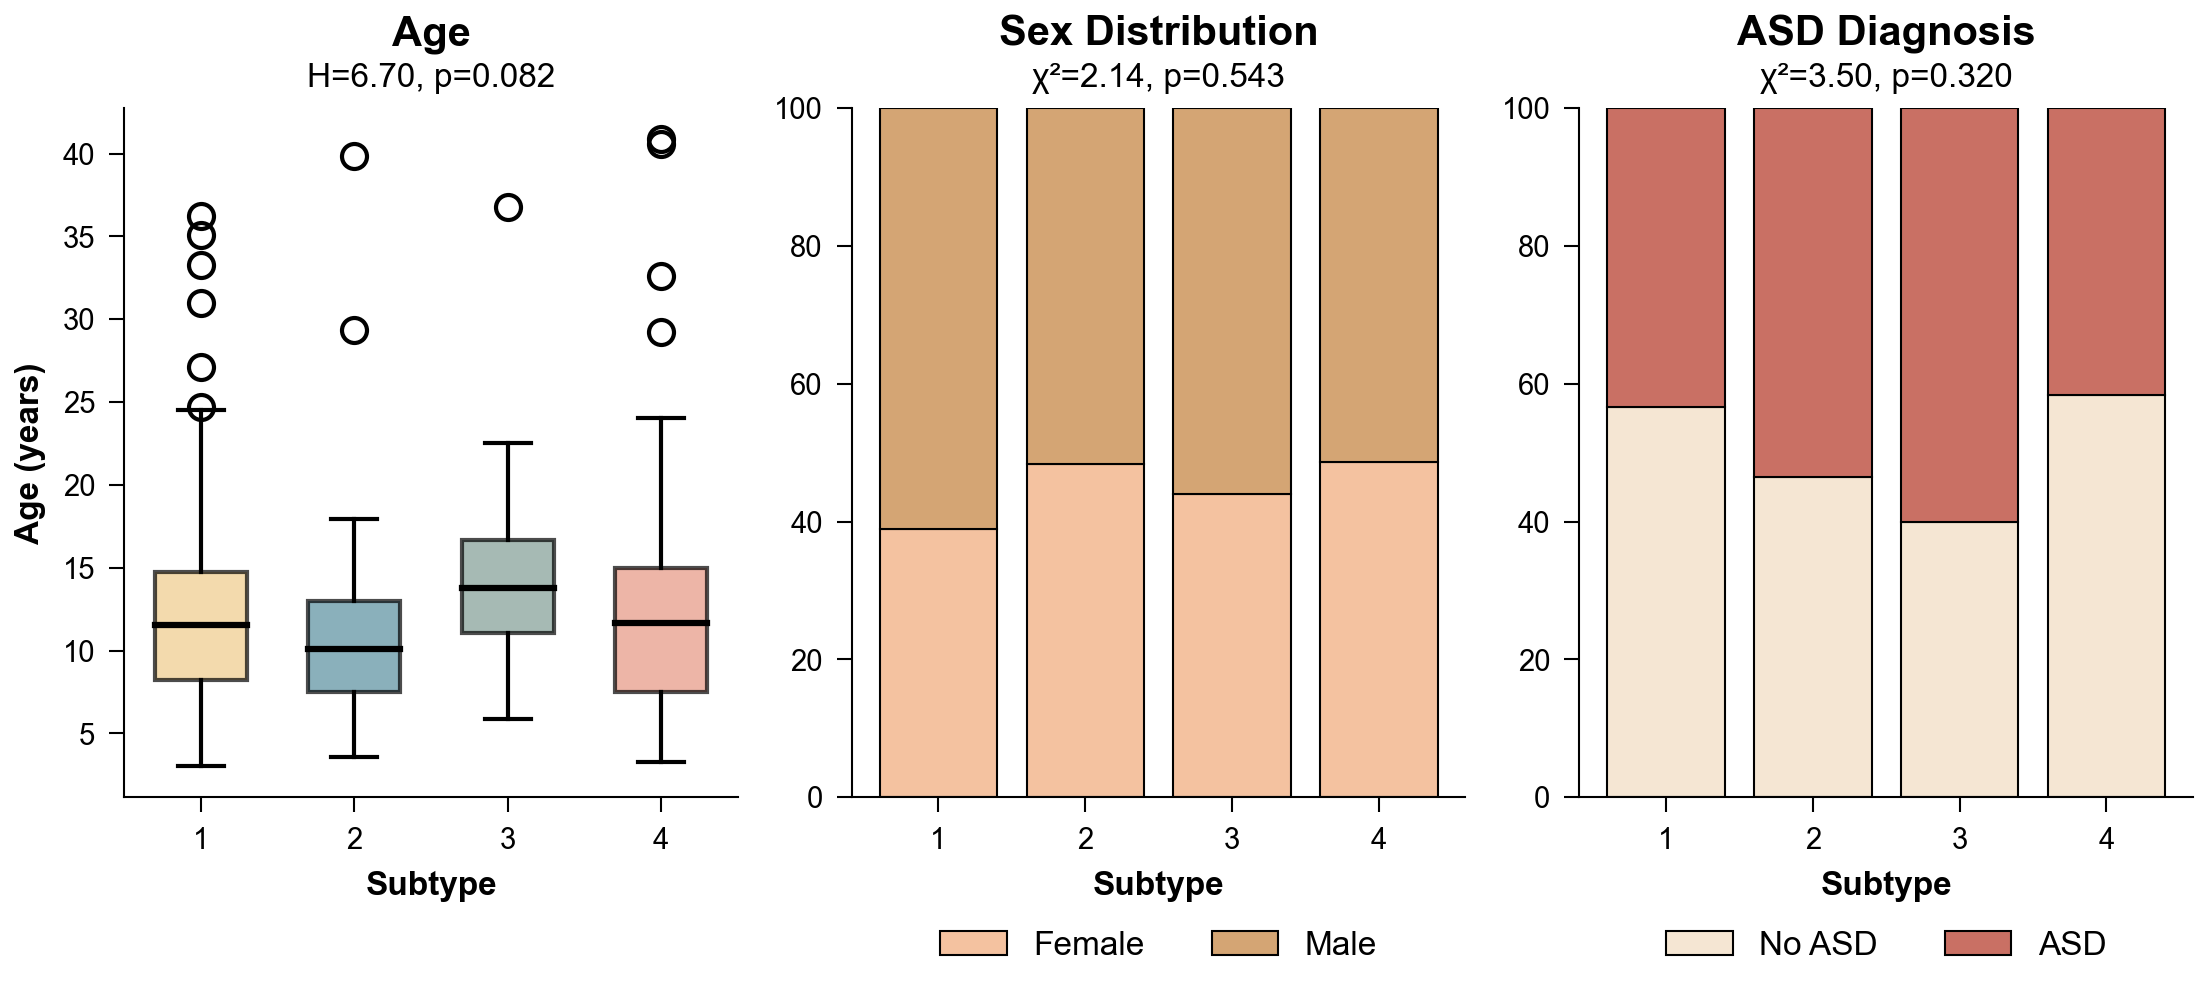


FIGURE 1E: DEMOGRAPHIC STATISTICS

Age: H=6.70, p=0.082, η²=0.026
Sex: χ²=2.14, p=0.543, V=0.091
ASD: χ²=3.50, p=0.320, V=0.117

→ Diagnostic Transcendence: No demographic differences across subtypes
✓ Figure 1C generated with statistics


In [33]:
"""
═══════════════════════════════════════════════════════════════════════════════
FIGURE 1C: DEMOGRAPHICS BY SUBTYPE
═══════════════════════════════════════════════════════════════════════════════
"""

# Prepare demographic data
demo_vars = ['eeg_age', 'sex', 'asd']

# Test demographics
age_test = comprehensive_test_continuous(merged_data, 'eeg_age')
sex_test = comprehensive_test_categorical(merged_data, 'sex')
asd_test = comprehensive_test_categorical(merged_data, 'asd')

# Create figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(7.5, 3.5))

# Panel C1: Age distribution
age_data = merged_data[['hc_cluster', 'eeg_age']].dropna()
bp1 = ax1.boxplot([age_data[age_data['hc_cluster'] == c]['eeg_age'].values 
                    for c in sorted(age_data['hc_cluster'].unique())],
                   positions=range(4), widths=0.6, patch_artist=True)
for i, patch in enumerate(bp1['boxes']):
    patch.set_facecolor(PALETTE_LIST[i])
    patch.set_alpha(0.7)

# Set median lines to black
for median in bp1['medians']:
    median.set_color('black')
    median.set_linewidth(1.5)

ax1.set_xlabel('Subtype', fontsize=8, fontweight='bold')
ax1.set_ylabel('Age (years)', fontsize=8, fontweight='bold')
ax1.set_title('Age', fontsize=10, fontweight='bold', loc='center', pad=15)
ax1.text(0.5, 1.02, f'H={age_test["statistic"]:.2f}, p={age_test["p_value"]:.3f}',
         transform=ax1.transAxes, fontsize=8, ha='center', va='bottom')
ax1.set_xticks(range(4))
ax1.set_xticklabels([f'{i+1}' for i in range(4)])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Panel C2: Sex distribution
sex_data = merged_data[['hc_cluster', 'sex']].dropna()
sex_counts = pd.crosstab(sex_data['hc_cluster'], sex_data['sex'], normalize='index') * 100

# Define warm-toned colors for sex (handle both uppercase and lowercase)
sex_colors = {
    'Female': '#F4C2A0', 'female': '#F4C2A0',  # Soft peach
    'Male': '#D4A574', 'male': '#D4A574'  # Warm gold
}

bottom = np.zeros(4)
for sex_val in sorted(sex_counts.columns):  # Iterate over actual sex values
    values = sex_counts[sex_val].values
    color = sex_colors.get(sex_val, '#CCC')
    # Capitalize label for display
    label = str(sex_val).capitalize() if isinstance(sex_val, str) else sex_val
    ax2.bar(range(4), values, bottom=bottom, label=label,
            color=color, 
            edgecolor='black', linewidth=0.5)
    bottom += values

ax2.set_xlabel('Subtype', fontsize=8, fontweight='bold')
ax2.set_title('Sex Distribution', fontsize=10, fontweight='bold', loc='center', pad=15)
ax2.text(0.5, 1.02, f'χ²={sex_test["statistic"]:.2f}, p={sex_test["p_value"]:.3f}',
         transform=ax2.transAxes, fontsize=8, ha='center', va='bottom')
ax2.set_xticks(range(4))
ax2.set_xticklabels([f'{i+1}' for i in range(4)])
ax2.set_ylim(0, 100)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
# Horizontal legend below plot
ax2.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.15), 
           ncol=2, frameon=False)

# Panel C3: ASD diagnosis
asd_data = merged_data[['hc_cluster', 'asd']].dropna()
asd_counts = pd.crosstab(asd_data['hc_cluster'], asd_data['asd'], normalize='index') * 100

# Define warm-toned colors for ASD diagnosis
asd_colors = {0: '#F5E6D3', 1: '#C97064'}  # Cream/beige for No ASD, terracotta for ASD
asd_labels = {0: 'No ASD', 1: 'ASD'}

bottom = np.zeros(4)
for asd_val in sorted(asd_counts.columns):  # Iterate over actual ASD values
    values = asd_counts[asd_val].values
    ax3.bar(range(4), values, bottom=bottom, 
            label=asd_labels.get(asd_val, str(asd_val)),
            color=asd_colors.get(asd_val, '#CCC'),
            edgecolor='black', linewidth=0.5)
    bottom += values

ax3.set_xlabel('Subtype', fontsize=8, fontweight='bold')
ax3.set_title('ASD Diagnosis', fontsize=10, fontweight='bold', loc='center', pad=15)
ax3.text(0.5, 1.02, f'χ²={asd_test["statistic"]:.2f}, p={asd_test["p_value"]:.3f}',
         transform=ax3.transAxes, fontsize=8, ha='center', va='bottom')
ax3.set_xticks(range(4))
ax3.set_xticklabels([f'{i+1}' for i in range(4)])
ax3.set_ylim(0, 100)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
# Horizontal legend below plot
ax3.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.15), 
           ncol=2, frameon=False)

plt.tight_layout()
plt.savefig(FIGURE_OUTPUT / 'Figure1E_Demographics.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURE_OUTPUT / 'Figure1E_Demographics.pdf', bbox_inches='tight')
plt.show()

# Print statistics
print("\n" + "="*70)
print("FIGURE 1E: DEMOGRAPHIC STATISTICS")
print("="*70)
print(f"\nAge: H={age_test['statistic']:.2f}, p={age_test['p_value']:.3f}, η²={age_test['effect_size']:.3f}")
print(f"Sex: χ²={sex_test['statistic']:.2f}, p={sex_test['p_value']:.3f}, V={sex_test['effect_size']:.3f}")
print(f"ASD: χ²={asd_test['statistic']:.2f}, p={asd_test['p_value']:.3f}, V={asd_test['effect_size']:.3f}")
print("\n→ Diagnostic Transcendence: No demographic differences across subtypes")
print("✓ Figure 1C generated with statistics")




---
---
# FIGURE 2: LANGUAGE OUTCOME ASSOCIATIONS
---
---

### Panel 2A: ABAS Communication Scores

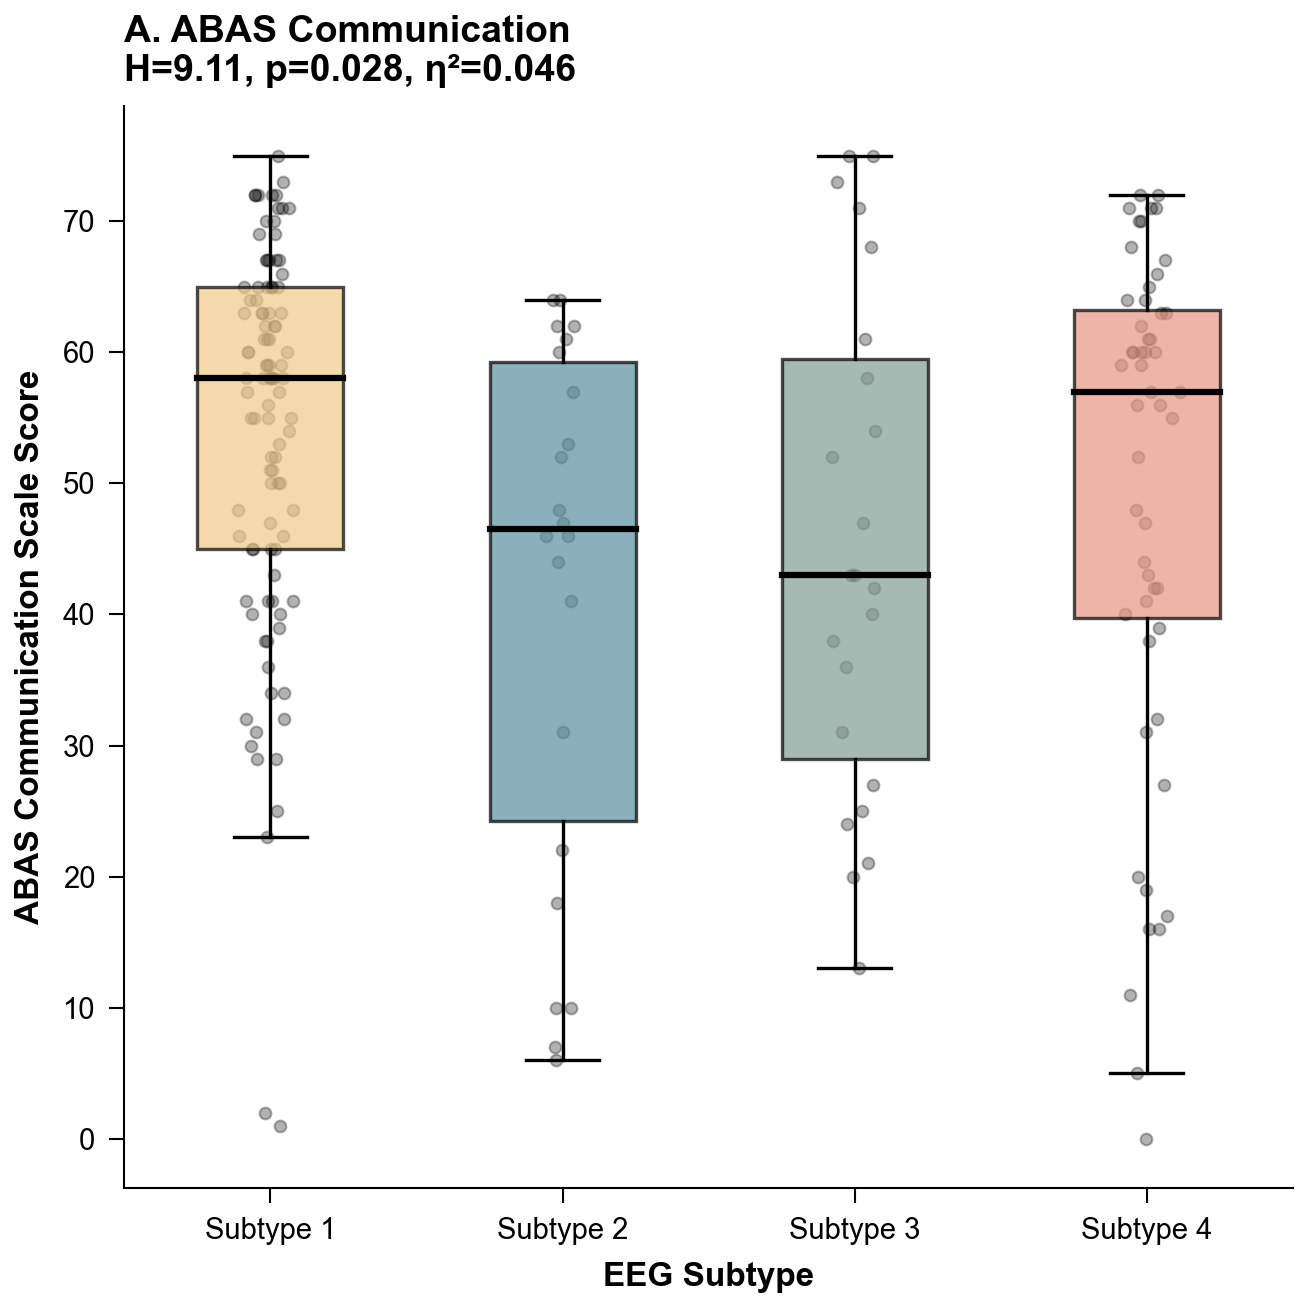


FIGURE 2A: ABAS COMMUNICATION STATISTICS
Kruskal-Wallis: H=9.11, p=0.027841, η²=0.046
Sample size: n=198

Post-hoc Dunn's test (Bonferroni corrected):


,0,1,2,3
0,1.0000,0.0593,0.2663,1.0000
1,0.0593,1.0000,1.0000,0.4984
2,0.2663,1.0000,1.0000,1.0000
3,1.0000,0.4984,1.0000,1.0000


✓ Figure 2A generated


In [12]:
"""
═══════════════════════════════════════════════════════════════════════════════
FIGURE 2A: ABAS COMMUNICATION BY SUBTYPE
═══════════════════════════════════════════════════════════════════════════════
"""

# Prepare ABAS data
abas_data = merged_data[['hc_cluster', 'subtype', 'abas_communication']].dropna()

# Statistical test
abas_test = comprehensive_test_continuous(abas_data, 'abas_communication')

# Post-hoc Dunn's test
dunn_abas = sp.posthoc_dunn(abas_data, val_col='abas_communication', 
                             group_col='hc_cluster', p_adjust='bonferroni')

# Identify significant pairs for ABAS
sig_pairs_abas = []
clusters = sorted(abas_data['hc_cluster'].unique())
for i, c1 in enumerate(clusters):
    for c2 in clusters[i+1:]:
        p_val = dunn_abas.loc[c1, c2]
        if p_val < 0.05:
            sig_pairs_abas.append((int(c1), int(c2), p_val))

# Create figure
fig, ax = plt.subplots(figsize=(4.5, 4.5))

# Box plot with individual points - NO OUTLIERS SHOWN (showfliers=False)
bp = ax.boxplot([abas_data[abas_data['hc_cluster'] == c]['abas_communication'].values 
                 for c in sorted(abas_data['hc_cluster'].unique())],
                positions=range(4), widths=0.5, patch_artist=True,
                showfliers=False,
                medianprops=dict(color='black', linewidth=1.5),
                boxprops=dict(linewidth=0.8),
                whiskerprops=dict(linewidth=0.8),
                capprops=dict(linewidth=0.8))

for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(PALETTE_LIST[i])
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')

# Add individual points
for i, cluster in enumerate(sorted(abas_data['hc_cluster'].unique())):
    y_vals = abas_data[abas_data['hc_cluster'] == cluster]['abas_communication'].values
    x_vals = np.random.normal(i, 0.04, size=len(y_vals))
    ax.scatter(x_vals, y_vals, alpha=0.3, s=8, color='black')

# Add significance brackets if any significant pairs
if sig_pairs_abas:
    y_max = abas_data['abas_communication'].max()
    y_range = abas_data['abas_communication'].max() - abas_data['abas_communication'].min()
    
    for pair_idx, (c1, c2, p_val) in enumerate(sig_pairs_abas):
        y_bracket = y_max + (y_range * 0.08 * (pair_idx + 1))
        
        # Draw bracket
        ax.plot([c1, c1, c2, c2], 
                [y_bracket, y_bracket + y_range*0.02, y_bracket + y_range*0.02, y_bracket],
                'k-', linewidth=1.0)
        
        # Add p-value label
        ax.text((c1 + c2) / 2, y_bracket + y_range*0.03, 
                f'p={p_val:.3f}*', ha='center', va='bottom', 
                fontsize=7, fontweight='bold')

# Formatting - NO SAMPLE SIZES
ax.set_xlabel('EEG Subtype', fontsize=8, fontweight='bold')
ax.set_ylabel('ABAS Communication Scale Score', fontsize=8, fontweight='bold')
ax.set_title(f'A. ABAS Communication\nH={abas_test["statistic"]:.2f}, p={abas_test["p_value"]:.3f}, η²={abas_test["effect_size"]:.3f}',
             fontsize=9, fontweight='bold', loc='left')
ax.set_xticks(range(4))
ax.set_xticklabels([f'Subtype {i+1}' for i in range(4)])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_OUTPUT / 'Figure2A_ABAS.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURE_OUTPUT / 'Figure2A_ABAS.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("FIGURE 2A: ABAS COMMUNICATION STATISTICS")
print("="*70)
print(f"Kruskal-Wallis: H={abas_test['statistic']:.2f}, p={abas_test['p_value']:.6f}, η²={abas_test['effect_size']:.3f}")
print(f"Sample size: n={abas_test['n']}")
print("\nPost-hoc Dunn's test (Bonferroni corrected):")
display(dunn_abas.round(4))

print("✓ Figure 2A generated")

In [13]:
merged_data

,subject,hc_cluster,eeg_age,site,sex,asd,ndd,group,age_group,fam_id,...,ppvt5_ss,evt3_ss,history_language_impairments,non_verbal_language_impairment,expressive_language_delay,receptive_language_delay,age_first_words,age_first_sentences,age_respond_to_name,subtype
0,1089P,2,7.19,hsj,female,1.0,ndd,proband,child,1089,...,NaN,NaN,1.0,0.0,1.0,1.0,late,late,late,Subtype 3
1,1093S2,3,4.20,hsj,female,1.0,control,sibling,child,1093,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Subtype 4
2,0150P,0,10.21,hsj,male,1.0,ndd,proband,child,150,...,NaN,NaN,1.0,0.0,1.0,1.0,late,late,late,Subtype 1
3,1256S1,0,17.33,hsj,male,1.0,ndd,sibling,child,1256,...,NaN,NaN,0.0,NaN,NaN,NaN,early,early,early,Subtype 1
4,0126P,0,8.29,hsj,male,1.0,ndd,proband,child,126,...,NaN,NaN,1.0,0.0,1.0,0.0,early,early,early,Subtype 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,1001P,3,6.92,hsj,male,1.0,ndd,proband,child,1001,...,NaN,NaN,0.0,NaN,NaN,NaN,late,late,early,Subtype 4
253,0326P,0,10.84,mni,female,1.0,ndd,proband,child,326,...,46.0,60.0,1.0,NaN,1.0,NaN,early,late,early,Subtype 1
254,0288S1,1,5.07,mni,male,1.0,ndd,sibling,child,288,...,NaN,NaN,NaN,NaN,NaN,NaN,early,never,late,Subtype 2
255,1162P,3,6.54,hsj,male,1.0,ndd,proband,child,1162,...,NaN,NaN,0.0,NaN,NaN,NaN,late,late,late,Subtype 4


### Panel 2B: Wechsler Verbal IQ

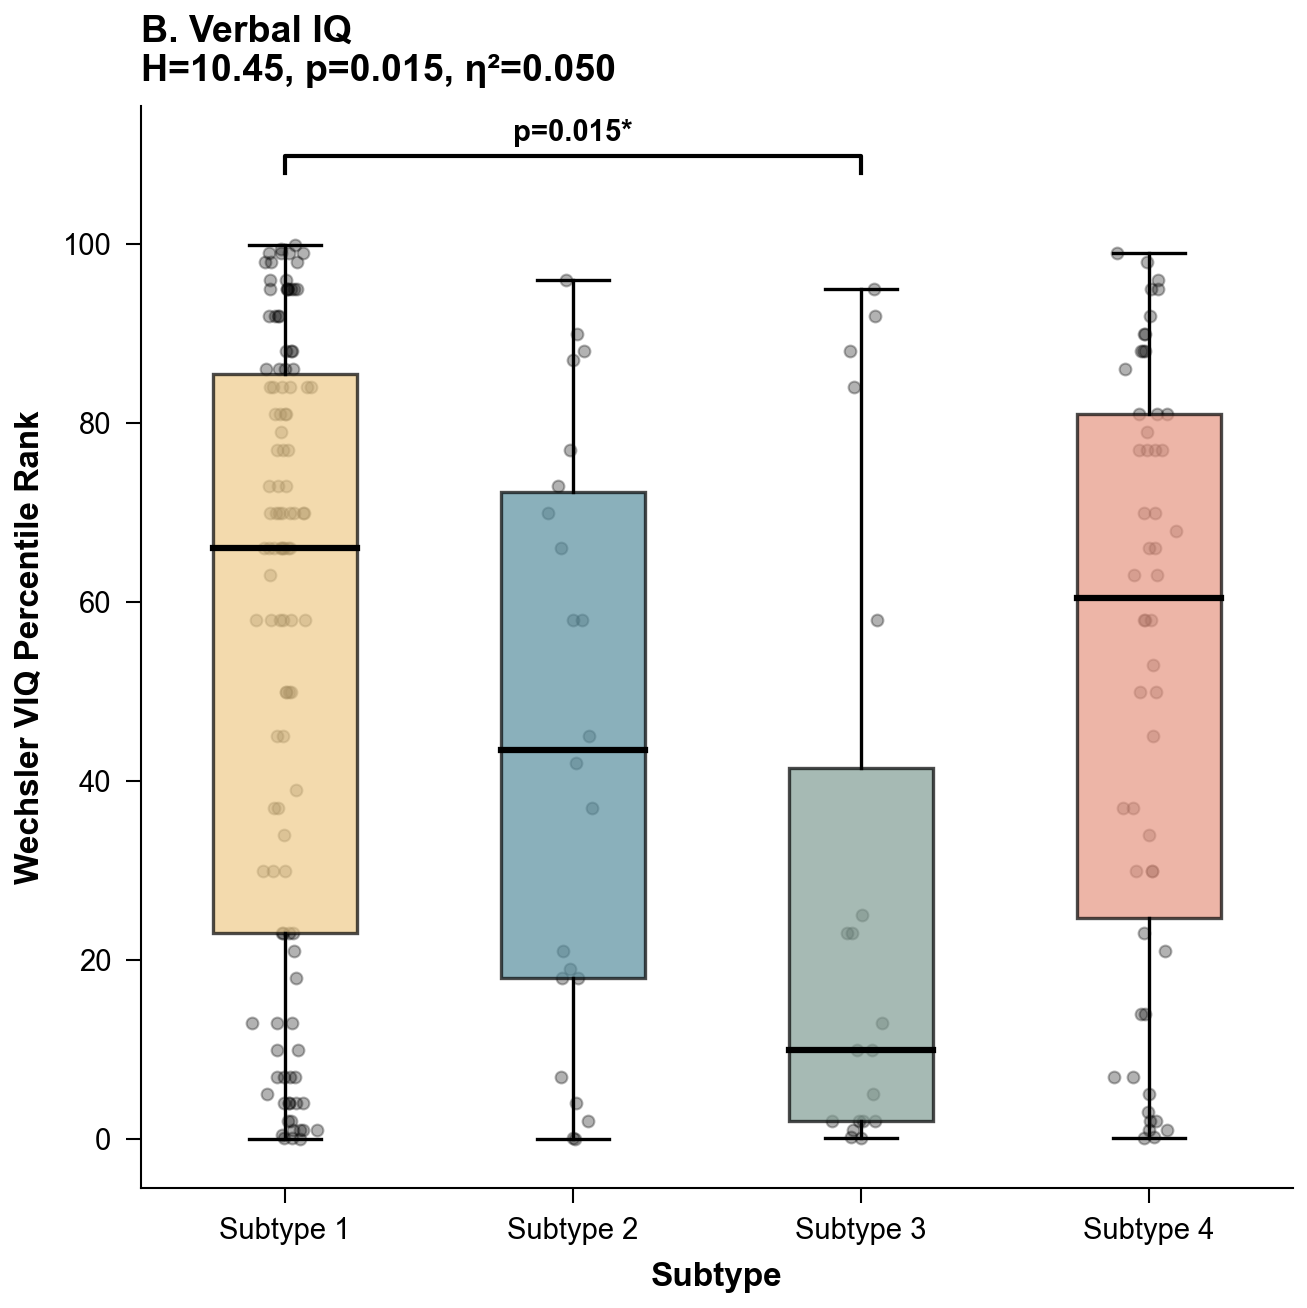


FIGURE 2B: WECHSLER VIQ STATISTICS
Kruskal-Wallis: H=10.45, p=0.015098, η²=0.050
Sample size: n=209

Post-hoc Dunn's test (Bonferroni corrected):


,0,1,2,3
0,1.0000,0.7106,0.0148,1.0000
1,0.7106,1.0000,1.0000,1.0000
2,0.0148,1.0000,1.0000,0.0987
3,1.0000,1.0000,0.0987,1.0000



Significant pairwise comparisons: 1
  Subtype 1 vs Subtype 3: p=0.0148, medians: 66.0 vs 10.0
✓ Figure 2B generated


In [46]:
"""
═══════════════════════════════════════════════════════════════════════════════
FIGURE 2B: WECHSLER VIQ BY SUBTYPE (WITH POST-HOC BRACKETS)
═══════════════════════════════════════════════════════════════════════════════
"""

# Prepare VIQ data
viq_data = merged_data[['hc_cluster', 'subtype', 'weschler_verbal_rank']].dropna()

# Statistical test
viq_test = comprehensive_test_continuous(viq_data, 'weschler_verbal_rank')

# Post-hoc Dunn's test
dunn_viq = sp.posthoc_dunn(viq_data, val_col='weschler_verbal_rank', 
                            group_col='hc_cluster', p_adjust='bonferroni')

# Identify significant pairs
sig_pairs = []
clusters = sorted(viq_data['hc_cluster'].unique())
for i, c1 in enumerate(clusters):
    for c2 in clusters[i+1:]:
        p_val = dunn_viq.loc[c1, c2]
        if p_val < 0.05:
            sig_pairs.append((int(c1), int(c2), p_val))

# Create figure
fig, ax = plt.subplots(figsize=(4.5, 4.5))

# Box plot
bp = ax.boxplot([viq_data[viq_data['hc_cluster'] == c]['weschler_verbal_rank'].values 
                 for c in sorted(viq_data['hc_cluster'].unique())],
                positions=range(4), widths=0.5, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.5),
                boxprops=dict(linewidth=0.8),
                whiskerprops=dict(linewidth=0.8),
                capprops=dict(linewidth=0.8))

for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(PALETTE_LIST[i])
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')

# Add individual points
for i, cluster in enumerate(sorted(viq_data['hc_cluster'].unique())):
    y_vals = viq_data[viq_data['hc_cluster'] == cluster]['weschler_verbal_rank'].values
    x_vals = np.random.normal(i, 0.04, size=len(y_vals))
    ax.scatter(x_vals, y_vals, alpha=0.3, s=8, color='black')

# Add significance brackets
if sig_pairs:
    y_max = viq_data['weschler_verbal_rank'].max()
    y_range = viq_data['weschler_verbal_rank'].max() - viq_data['weschler_verbal_rank'].min()
    
    for pair_idx, (c1, c2, p_val) in enumerate(sig_pairs):
        y_bracket = y_max + (y_range * 0.08 * (pair_idx + 1))
        
        # Draw bracket
        ax.plot([c1, c1, c2, c2], 
                [y_bracket, y_bracket + y_range*0.02, y_bracket + y_range*0.02, y_bracket],
                'k-', linewidth=1.0)
        
        # Add p-value label
        ax.text((c1 + c2) / 2, y_bracket + y_range*0.03, 
                f'p={p_val:.3f}*', ha='center', va='bottom', 
                fontsize=7, fontweight='bold')

# Formatting - NO SAMPLE SIZES
ax.set_xlabel('Subtype', fontsize=8, fontweight='bold')
ax.set_ylabel('Wechsler VIQ Percentile Rank', fontsize=8, fontweight='bold')
ax.set_title(f'B. Verbal IQ\nH={viq_test["statistic"]:.2f}, p={viq_test["p_value"]:.3f}, η²={viq_test["effect_size"]:.3f}',
             fontsize=9, fontweight='bold', loc='left')
ax.set_xticks(range(4))
ax.set_xticklabels([f'Subtype {i+1}' for i in range(4)])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_OUTPUT / 'Figure2B_VIQ.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURE_OUTPUT / 'Figure2B_VIQ.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("FIGURE 2B: WECHSLER VIQ STATISTICS")
print("="*70)
print(f"Kruskal-Wallis: H={viq_test['statistic']:.2f}, p={viq_test['p_value']:.6f}, η²={viq_test['effect_size']:.3f}")
print(f"Sample size: n={viq_test['n']}")
print("\nPost-hoc Dunn's test (Bonferroni corrected):")
display(dunn_viq.round(4))
print(f"\nSignificant pairwise comparisons: {len(sig_pairs)}")
for c1, c2, p_val in sig_pairs:
    med1 = viq_data[viq_data['hc_cluster'] == c1]['weschler_verbal_rank'].median()
    med2 = viq_data[viq_data['hc_cluster'] == c2]['weschler_verbal_rank'].median()
    print(f"  Subtype {c1+1} vs Subtype {c2+1}: p={p_val:.4f}, medians: {med1:.1f} vs {med2:.1f}")

print("✓ Figure 2B generated")

### Panel 2C: Early Language Milestones Heatmap

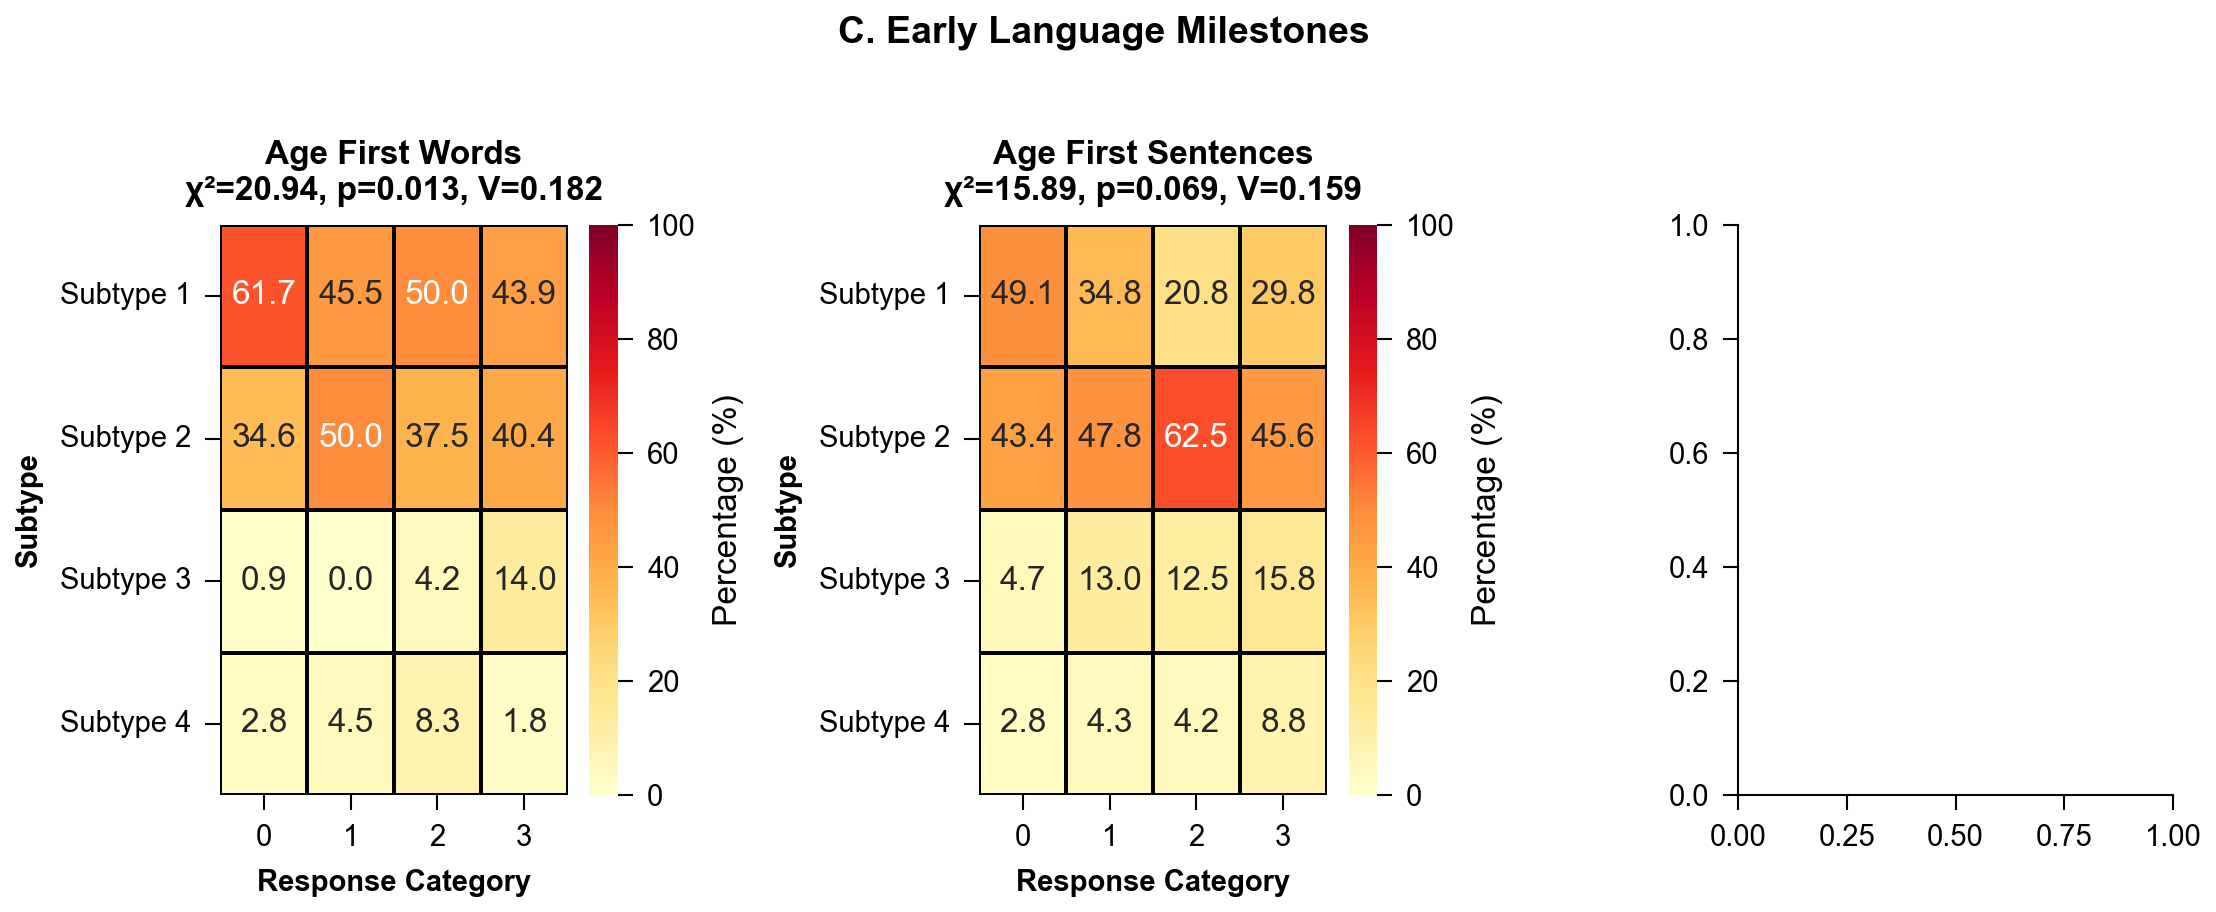


FIGURE 2C: LANGUAGE MILESTONE STATISTICS

Age First Words:
  χ² = 20.94
  p = 0.012925
  Cramér's V = 0.182
  n = 210

Age First Sentences:
  χ² = 15.89
  p = 0.069319
  Cramér's V = 0.159
  n = 210
✓ Figure 2C generated


In [15]:
"""
═══════════════════════════════════════════════════════════════════════════════
FIGURE 2C: EARLY LANGUAGE MILESTONES HEATMAP
═══════════════════════════════════════════════════════════════════════════════
"""

# Select milestone variables
milestone_vars = ['age_first_words', 'age_first_sentences', 'respond_to_name']

# Test each milestone
milestone_results = {}
for var in milestone_vars:
    if var in merged_data.columns:
        result = comprehensive_test_categorical(merged_data, var)
        milestone_results[var] = result

# Create contingency tables for visualization
fig, axes = plt.subplots(1, 3, figsize=(7.5, 3))

for idx, var in enumerate(milestone_vars):
    if var not in merged_data.columns:
        continue
    
    ax = axes[idx]
    
    # Create contingency table
    cont_data = merged_data[['hc_cluster', var]].dropna()
    contingency = pd.crosstab(cont_data['hc_cluster'], cont_data[var], normalize='index') * 100
    
    # Heatmap
    sns.heatmap(contingency.T, annot=True, fmt='.1f', cmap='YlOrRd', 
                cbar_kws={'label': 'Percentage (%)'}, ax=ax,
                linewidths=0.5, linecolor='black', vmin=0, vmax=100)
    
    # Get statistics
    result = milestone_results.get(var, {})
    chi2 = result.get('statistic', np.nan)
    p_val = result.get('p_value', np.nan)
    cramers_v = result.get('effect_size', np.nan)
    
    # Formatting
    var_name = VAR_NAMES.get(var, var)
    ax.set_title(f'{var_name}\nχ²={chi2:.2f}, p={p_val:.3f}, V={cramers_v:.3f}',
                 fontsize=8, fontweight='bold')
    ax.set_xlabel('Response Category', fontsize=7, fontweight='bold')
    ax.set_ylabel('Subtype', fontsize=7, fontweight='bold')
    ax.set_yticklabels([f'Subtype {int(i)+1}' for i in contingency.index], rotation=0)

plt.suptitle('C. Early Language Milestones', fontsize=9, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURE_OUTPUT / 'Figure2C_Milestones.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURE_OUTPUT / 'Figure2C_Milestones.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("FIGURE 2C: LANGUAGE MILESTONE STATISTICS")
print("="*70)
for var, result in milestone_results.items():
    var_name = VAR_NAMES.get(var, var)
    print(f"\n{var_name}:")
    print(f"  χ² = {result['statistic']:.2f}")
    print(f"  p = {result['p_value']:.6f}")
    print(f"  Cramér's V = {result['effect_size']:.3f}")
    print(f"  n = {result['n']}")

print("✓ Figure 2C generated")

---
---
# COMPLETE FIGURE 1: COMBINED PANELS
---
---

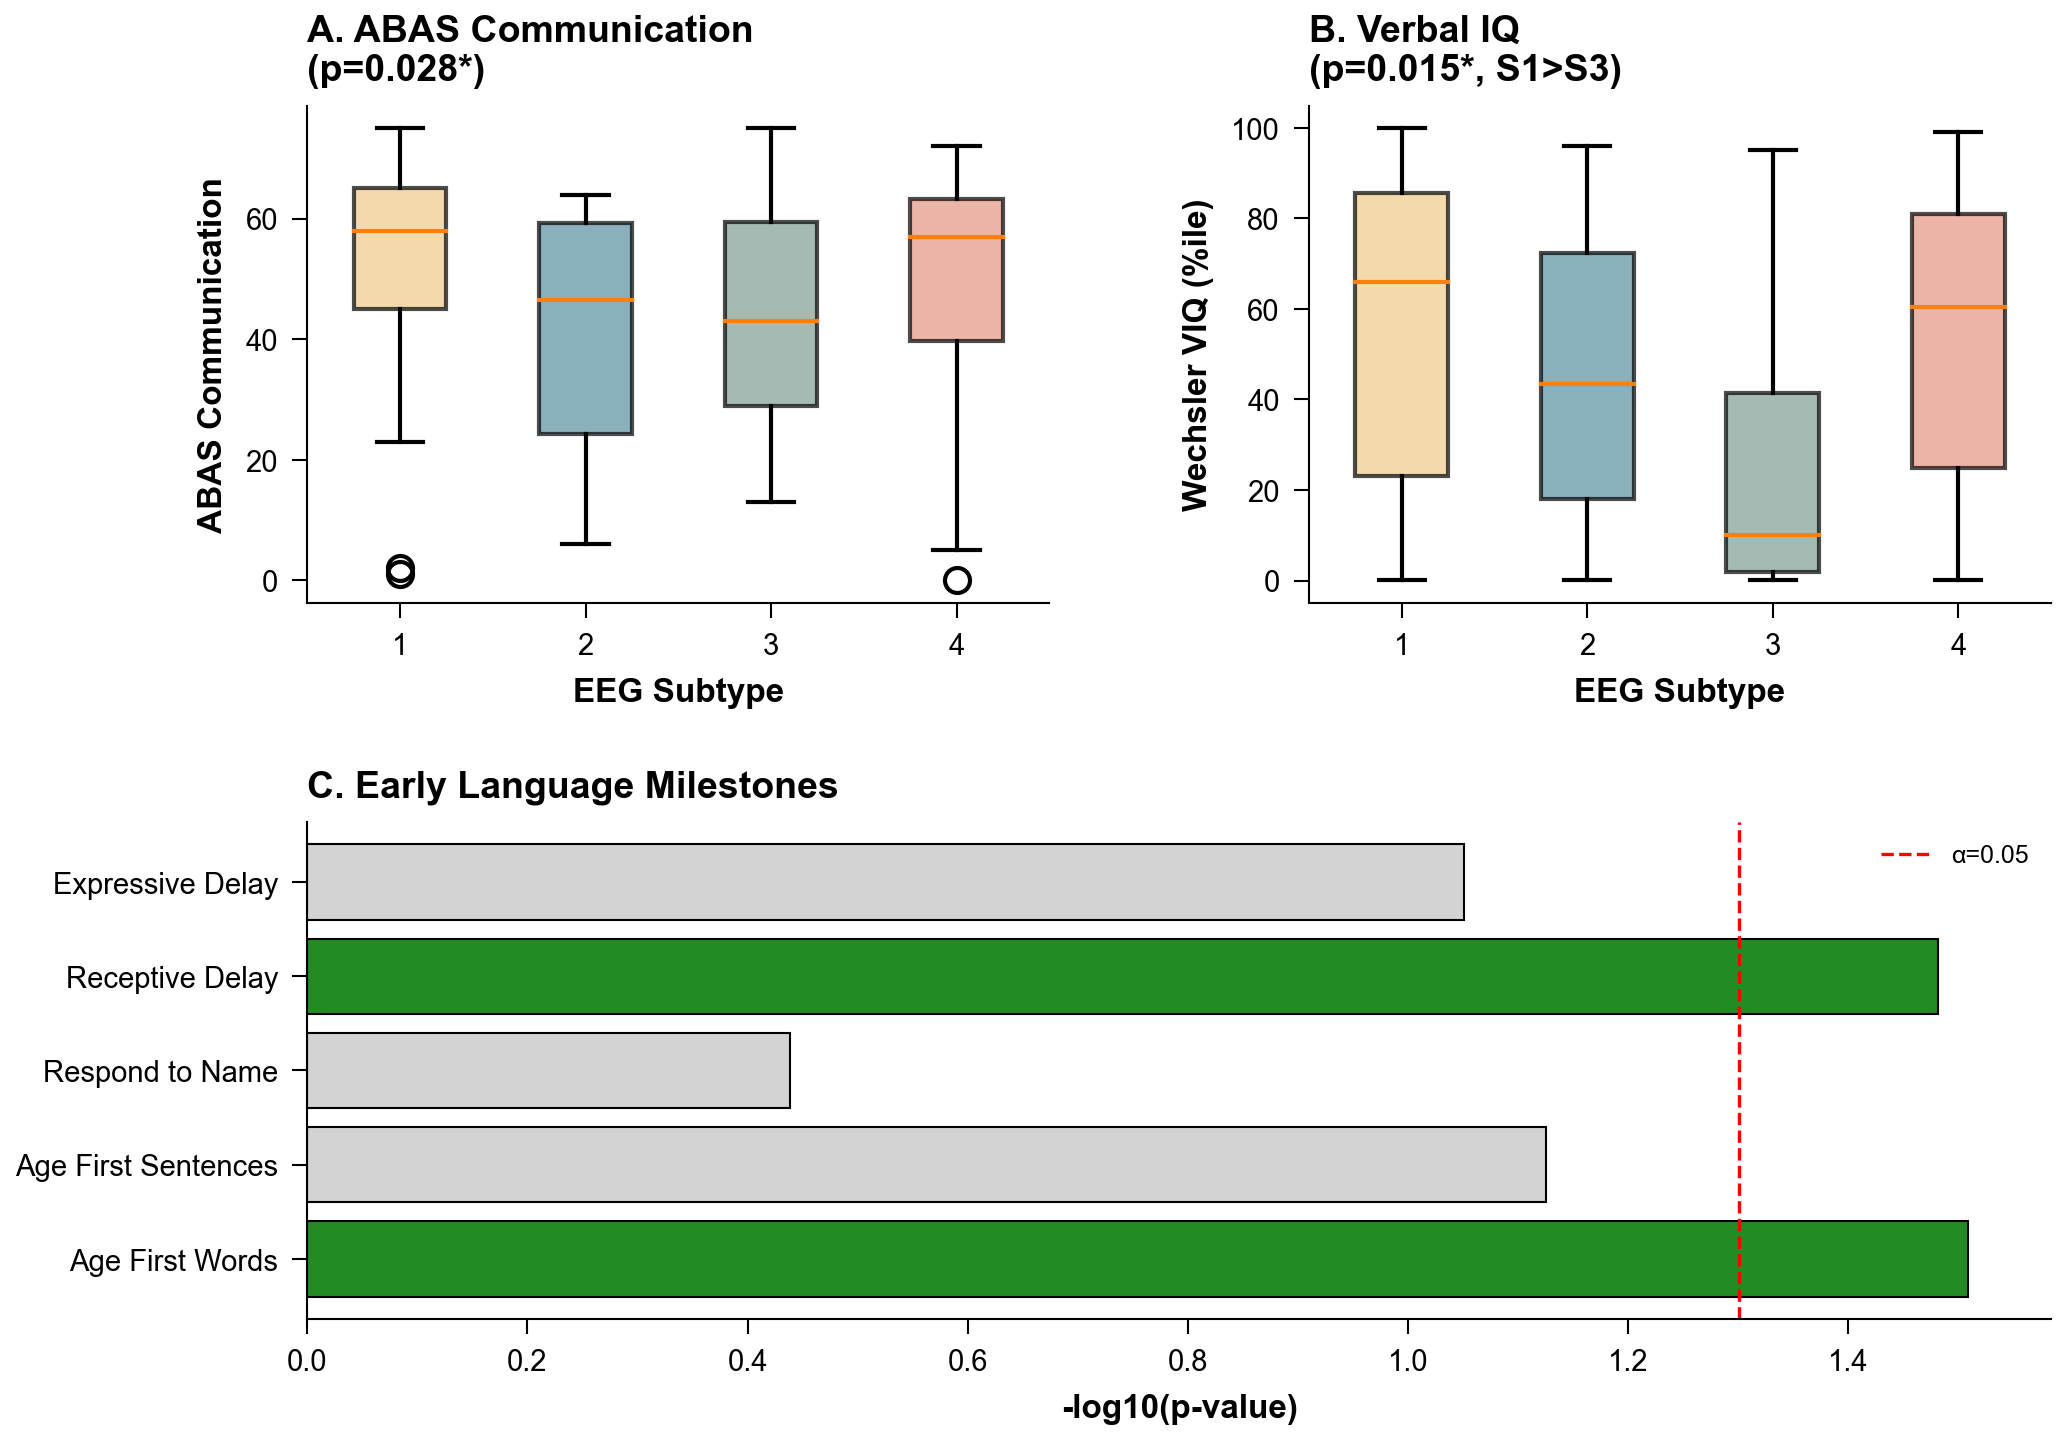

✓ Figure 2 COMPLETE generated


In [47]:
"""
═══════════════════════════════════════════════════════════════════════════════
FIGURE 2 COMPLETE: ALL PANELS COMBINED
═══════════════════════════════════════════════════════════════════════════════
"""

fig = plt.figure(figsize=(7.5, 9))
gs = GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.35,
              height_ratios=[1, 1, 1.3])

# Panel A: ABAS Communication
ax_abas = fig.add_subplot(gs[0, 0])
abas_data = merged_data[['hc_cluster', 'abas_communication']].dropna()

bp_abas = ax_abas.boxplot([abas_data[abas_data['hc_cluster'] == c]['abas_communication'].values 
                            for c in sorted(abas_data['hc_cluster'].unique())],
                           positions=range(4), widths=0.5, patch_artist=True)

for i, patch in enumerate(bp_abas['boxes']):
    patch.set_facecolor(PALETTE_LIST[i])
    patch.set_alpha(0.7)

ax_abas.set_xlabel('EEG Subtype', fontsize=8, fontweight='bold')
ax_abas.set_ylabel('ABAS Communication', fontsize=8, fontweight='bold')
ax_abas.set_title('A. ABAS Communication\n(p=0.028*)', fontsize=9, fontweight='bold', loc='left')
ax_abas.set_xticks(range(4))
ax_abas.set_xticklabels([f'{i+1}' for i in range(4)])
ax_abas.spines['top'].set_visible(False)
ax_abas.spines['right'].set_visible(False)

# Panel B: Wechsler VIQ
ax_viq = fig.add_subplot(gs[0, 1])
viq_data = merged_data[['hc_cluster', 'weschler_verbal_rank']].dropna()

bp_viq = ax_viq.boxplot([viq_data[viq_data['hc_cluster'] == c]['weschler_verbal_rank'].values 
                          for c in sorted(viq_data['hc_cluster'].unique())],
                         positions=range(4), widths=0.5, patch_artist=True)

for i, patch in enumerate(bp_viq['boxes']):
    patch.set_facecolor(PALETTE_LIST[i])
    patch.set_alpha(0.7)

ax_viq.set_xlabel('EEG Subtype', fontsize=8, fontweight='bold')
ax_viq.set_ylabel('Wechsler VIQ (%ile)', fontsize=8, fontweight='bold')
ax_viq.set_title('B. Verbal IQ\n(p=0.015*, S1>S3)', fontsize=9, fontweight='bold', loc='left')
ax_viq.set_xticks(range(4))
ax_viq.set_xticklabels([f'{i+1}' for i in range(4)])
ax_viq.spines['top'].set_visible(False)
ax_viq.spines['right'].set_visible(False)

# Panel C: Language Milestones (simplified representation)
ax_mile = fig.add_subplot(gs[1, :])
milestone_summary = {
    'Age First Words': 0.031,
    'Age First Sentences': 0.075,
    'Respond to Name': 0.364,
    'Receptive Delay': 0.033,
    'Expressive Delay': 0.089
}

y_pos = np.arange(len(milestone_summary))
p_vals = list(milestone_summary.values())
colors_mile = ['#228B22' if p < 0.05 else '#D3D3D3' for p in p_vals]

ax_mile.barh(y_pos, [-np.log10(p) for p in p_vals], color=colors_mile, 
             edgecolor='black', linewidth=0.5)
ax_mile.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=0.8, 
                label='α=0.05')
ax_mile.set_yticks(y_pos)
ax_mile.set_yticklabels(list(milestone_summary.keys()), fontsize=7)
ax_mile.set_xlabel('-log10(p-value)', fontsize=8, fontweight='bold')
ax_mile.set_title('C. Early Language Milestones', fontsize=9, fontweight='bold', loc='left')
ax_mile.spines['top'].set_visible(False)
ax_mile.spines['right'].set_visible(False)
ax_mile.legend(fontsize=6)

plt.savefig(FIGURE_OUTPUT / 'Figure2_Complete.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURE_OUTPUT / 'Figure2_Complete.pdf', bbox_inches='tight')
plt.show()

print("✓ Figure 2 COMPLETE generated")

## OPTION 1: Parallel Coordinates Plot (RECOMMENDED)

**Why this visualization:**
- ✓ Linear axes easier to interpret than circular radar plots
- ✓ Shows error bars (95% CI) for statistical rigor
- ✓ Clear visualization of which subtypes have similar/different patterns
- ✓ Modern, publication-ready style (appropriate for Nature Neuroscience)
- ✓ Easy to see exact normalized values and directionality
- ✓ Crossing lines indicate different rank orderings across measures

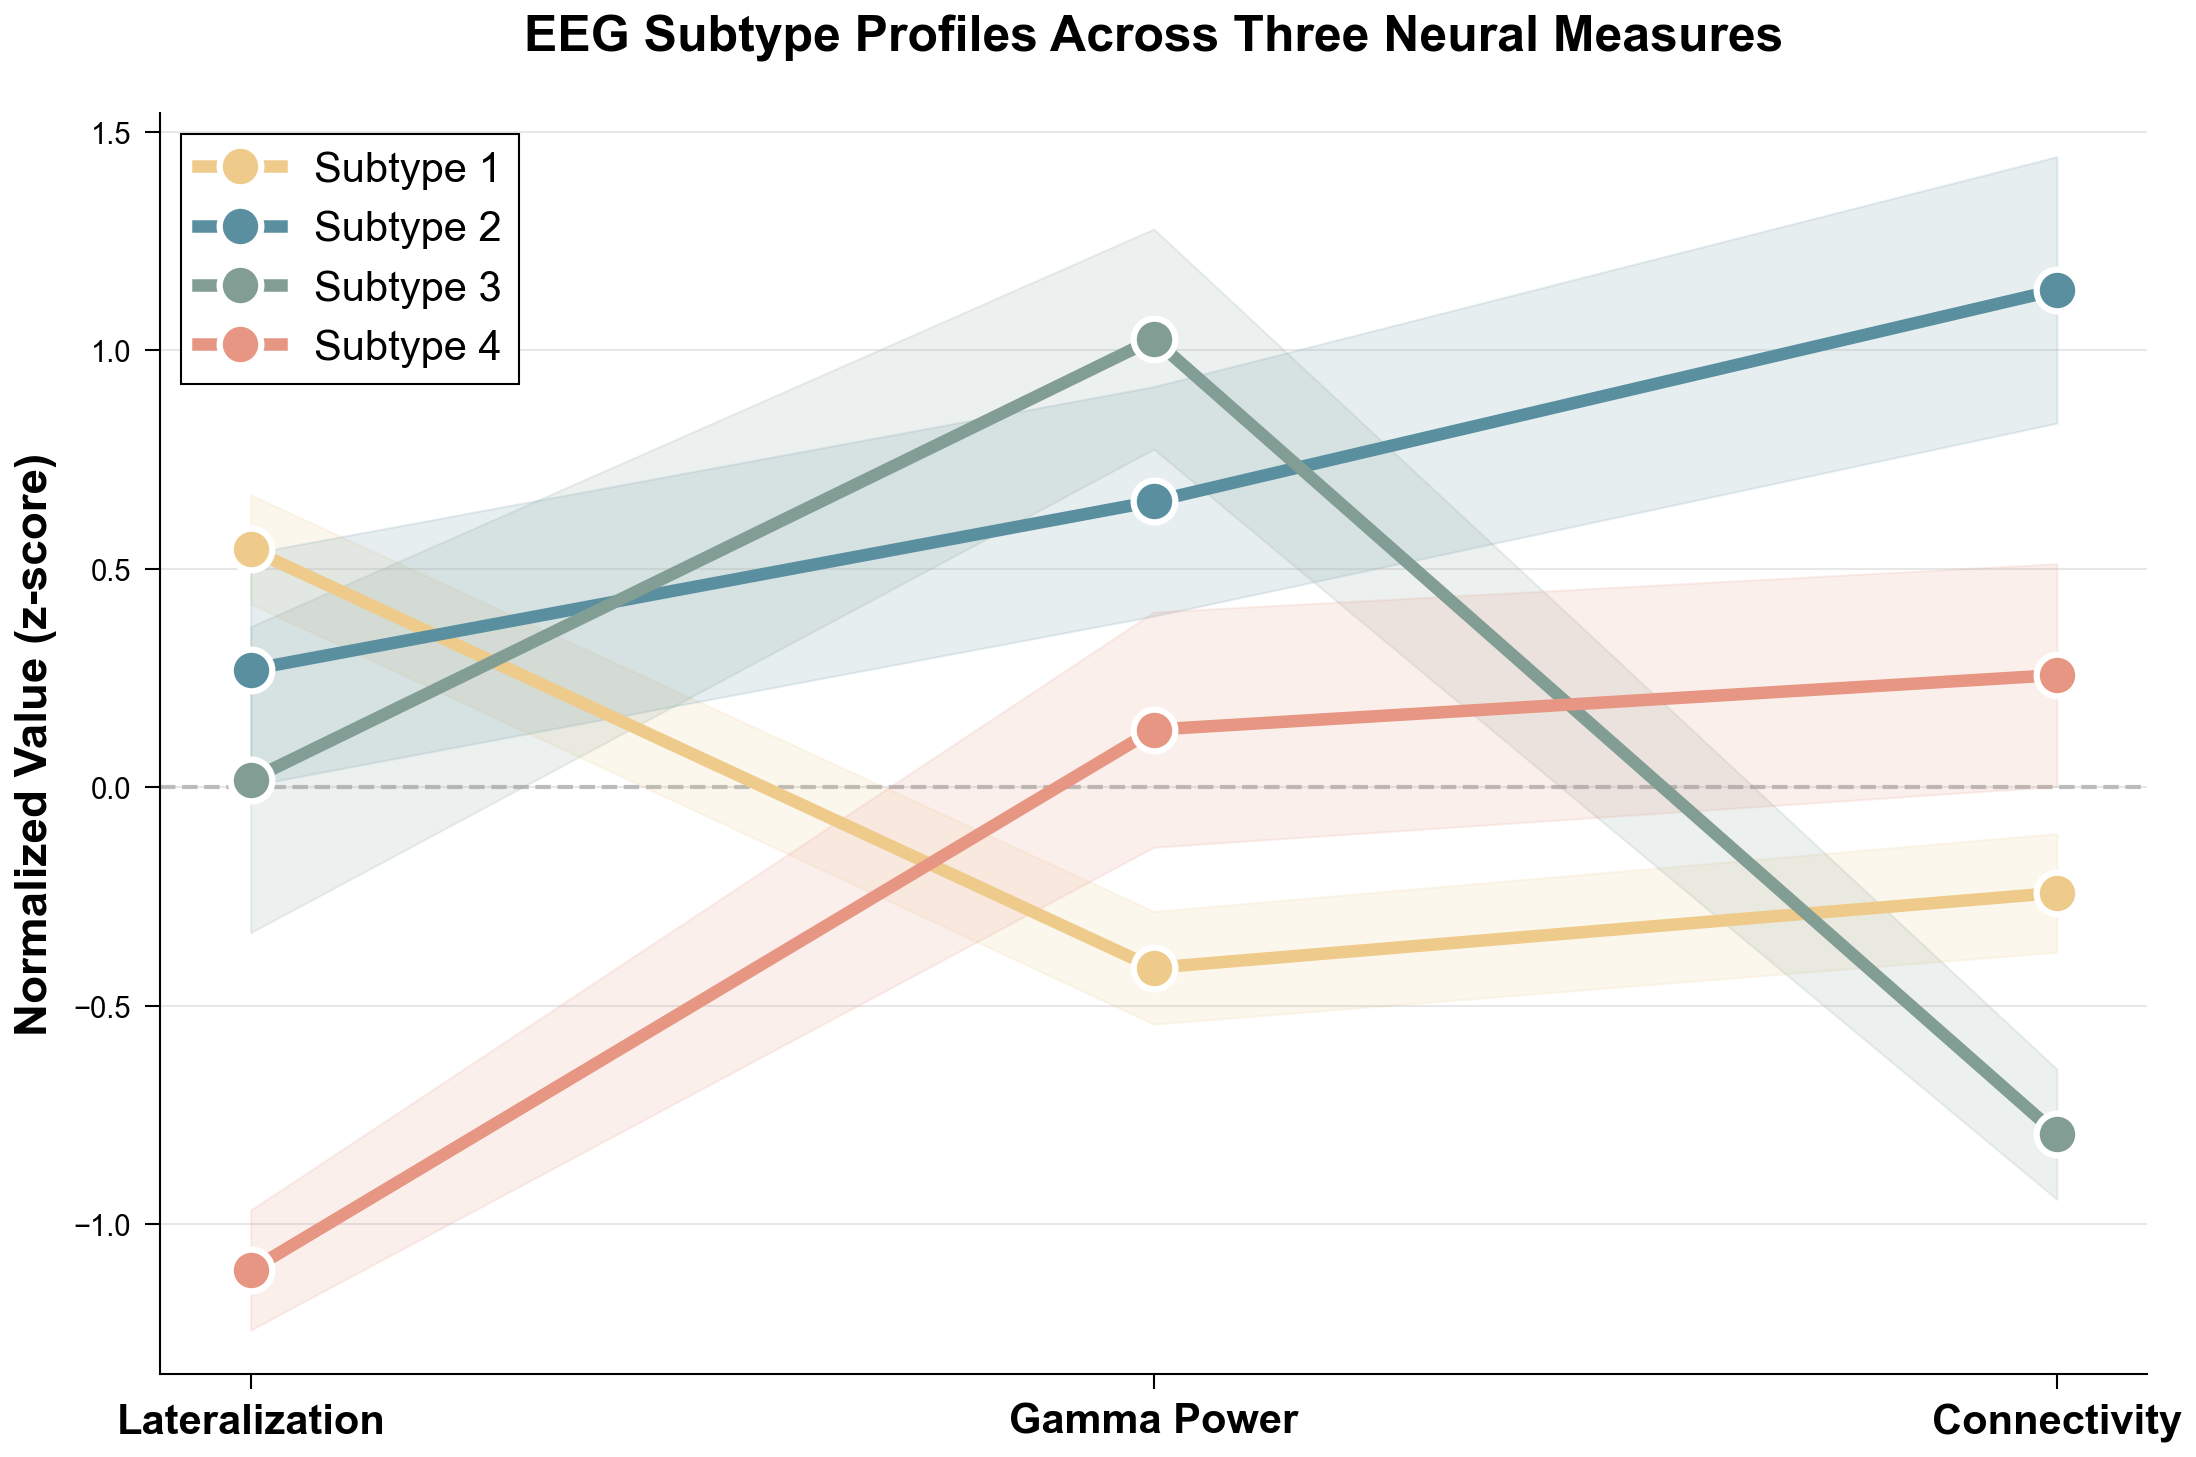


✓ Figure 4 (Parallel Coordinates) generated
  File saved as: Figure4_ParallelCoordinates.png/.pdf
  Shows normalized profiles with 95% confidence intervals


In [37]:
"""
═══════════════════════════════════════════════════════════════════════════════
FIGURE 4 OPTION 1: PARALLEL COORDINATES PLOT
═══════════════════════════════════════════════════════════════════════════════
"""

fig, ax = plt.subplots(figsize=(7.5, 5))

# Measure positions - SIMPLIFIED LABELS
measure_names_short = ['Lateralization', 'Gamma Power', 'Connectivity']
x_positions = np.arange(len(EEG_VARS))

# Plot each subtype's profile
for cluster in range(4):
    cluster_profile = profile_df[profile_df['cluster'] == cluster]
    means = cluster_profile['mean_z'].values
    ci_lower = cluster_profile['ci_lower'].values
    ci_upper = cluster_profile['ci_upper'].values
    
    # Plot line connecting measures
    ax.plot(x_positions, means, 'o-', 
            color=PALETTE_LIST[cluster], 
            linewidth=3, 
            markersize=10,
            label=f'Subtype {cluster + 1}',
            zorder=3,
            markeredgecolor='white',
            markeredgewidth=1.5)
    
    # Add 95% CI as shaded region
    ax.fill_between(x_positions, ci_lower, ci_upper,
                    color=PALETTE_LIST[cluster],
                    alpha=0.15,
                    zorder=1)

# Reference line at zero (population mean)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5, zorder=0)

# Styling with BETTER Y-AXIS LIMITS
ax.set_xticks(x_positions)
ax.set_xticklabels(measure_names_short, fontsize=10, fontweight='bold')
ax.set_ylabel('Normalized Value (z-score)', fontsize=11, fontweight='bold')
ax.set_title('EEG Subtype Profiles Across Three Neural Measures',
             fontsize=12, fontweight='bold', pad=15)

# FIXED Y-AXIS LIMITS - Show full range of data
all_means = profile_df['mean_z'].values
all_ci_lower = profile_df['ci_lower'].values
all_ci_upper = profile_df['ci_upper'].values
y_min = min(all_ci_lower.min(), all_means.min()) - 0.1
y_max = max(all_ci_upper.max(), all_means.max()) + 0.1
ax.set_ylim(y_min, y_max)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linewidth=0.5, zorder=0)

# SIMPLIFIED LEGEND - No sample sizes, larger font
# Let matplotlib automatically use the labels from the plot calls
ax.legend(fontsize=10, 
          loc='upper left',
          frameon=True,
          fancybox=False,
          edgecolor='black',
          framealpha=1)

plt.tight_layout()
plt.savefig(FIGURE_OUTPUT / 'Figure4_ParallelCoordinates.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURE_OUTPUT / 'Figure4_ParallelCoordinates.pdf', bbox_inches='tight')
plt.show()

print("\n✓ Figure 4 (Parallel Coordinates) generated")
print(f"  File saved as: Figure4_ParallelCoordinates.png/.pdf")
print(f"  Shows normalized profiles with 95% confidence intervals")

## OPTION 3: 2D Projection of 3D EEG Space (Individual Participants)

**New visualization showing all participants:**
- 2D projection of the 3D EEG measurement space
- Each dot represents one participant
- Colors indicate subtype membership
- Shows how subtypes cluster in the full 3-dimensional neural space
- Uses PCA to project from 3D to 2D while preserving maximum variance

FIGURE 4 OPTION 3: 2D PROJECTION OF 3D EEG SPACE

✓ PCA completed:
  PC1 explains 39.1% of variance
  PC2 explains 32.2% of variance
  Total variance explained: 71.2%


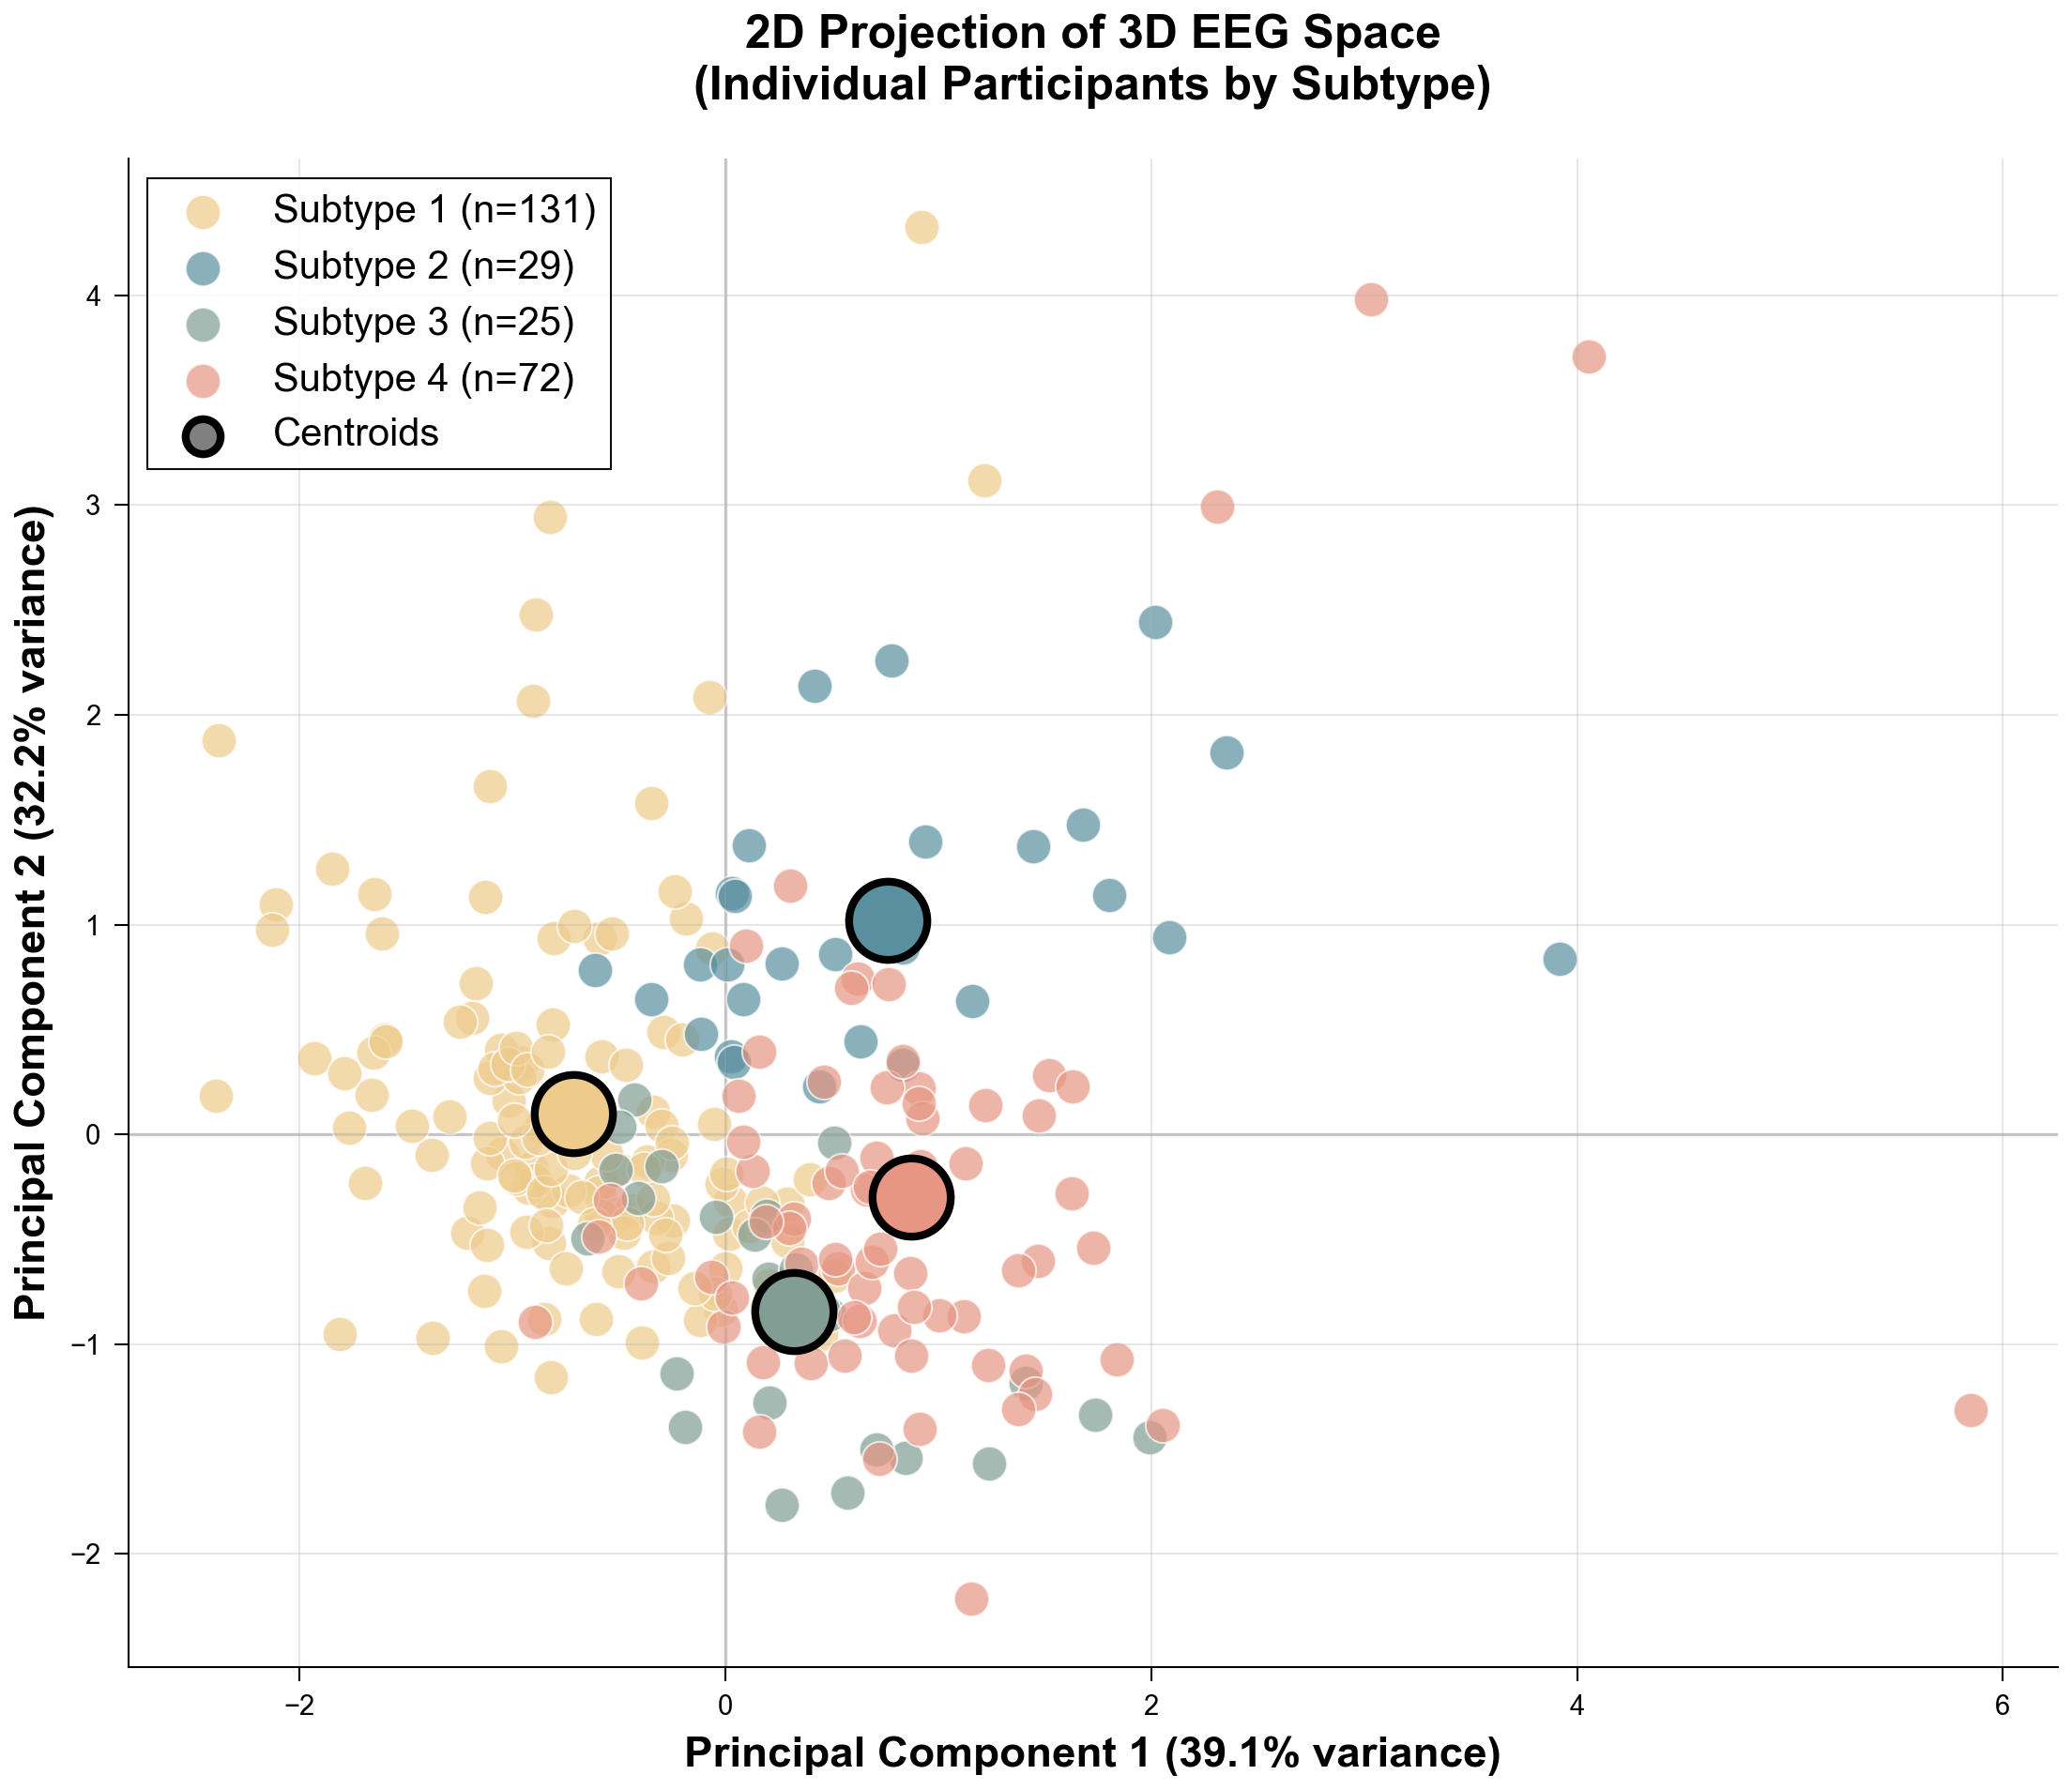


✓ Figure 4 Option 3 (2D Projection) generated
  File saved as: Figure4_3Dto2D_Projection.png/.pdf
  Shows 257 participants in 2D projection of 3D EEG space
  Centroids marked with large stars

PCA COMPONENT LOADINGS


,PC1,PC2
Frontal Lateralization Index,-0.612,0.457
"Gamma Power (log, age-adjusted)",0.661,-0.153
Connectivity (log),0.434,0.876



Interpretation: Component loadings show how each EEG measure
contributes to the principal components in the 2D projection.


In [229]:
"""
═══════════════════════════════════════════════════════════════════════════════
FIGURE 4 OPTION 3: 2D PROJECTION OF 3D EEG SPACE
═══════════════════════════════════════════════════════════════════════════════
Shows all individual participants in a 2D projection of the 3-dimensional
EEG measurement space (lateralization, gamma power, connectivity)
"""

from sklearn.decomposition import PCA

print("="*70)
print("FIGURE 4 OPTION 3: 2D PROJECTION OF 3D EEG SPACE")
print("="*70)

# Prepare data for PCA
eeg_3d_data = normalized_measures[['hc_cluster'] + [f'{var}_z' for var in EEG_VARS]].copy()

# Extract the 3 normalized EEG measures
X_3d = eeg_3d_data[[f'{var}_z' for var in EEG_VARS]].values
clusters = eeg_3d_data['hc_cluster'].values

# Apply PCA to reduce from 3D to 2D
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_3d)

# Calculate variance explained
var_explained = pca.explained_variance_ratio_
print(f"\n✓ PCA completed:")
print(f"  PC1 explains {var_explained[0]*100:.1f}% of variance")
print(f"  PC2 explains {var_explained[1]*100:.1f}% of variance")
print(f"  Total variance explained: {sum(var_explained)*100:.1f}%")

# Create the 2D scatter plot
fig, ax = plt.subplots(figsize=(7.5, 6.5))

# Plot each subtype
for cluster in range(4):
    mask = clusters == cluster
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[PALETTE_LIST[cluster]],
               label=f'Subtype {cluster + 1}',
               s=80,
               alpha=0.7,
               edgecolors='white',
               linewidth=0.5)

# Add subtype centroids
for cluster in range(4):
    mask = clusters == cluster
    centroid_x = X_2d[mask, 0].mean()
    centroid_y = X_2d[mask, 1].mean()
    
    # Large marker for centroid
    ax.scatter(centroid_x, centroid_y,
               c=[PALETTE_LIST[cluster]],
               s=400,
               marker='o',
               edgecolors='black',
               linewidth=2,
               zorder=10)

# Styling
ax.set_xlabel(f'Principal Component 1 ({var_explained[0]*100:.1f}% variance)',
              fontsize=11, fontweight='bold')
ax.set_ylabel(f'Principal Component 2 ({var_explained[1]*100:.1f}% variance)',
              fontsize=11, fontweight='bold')
ax.set_title('2D Projection of 3D EEG Space\n(Individual Participants by Subtype)',
             fontsize=12, fontweight='bold', pad=15)

# Grid and spines
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.4, zorder=0)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.4, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
legend_labels = [f'Subtype {i+1} (n={sum(clusters==i)})' for i in range(4)]
legend_labels.append('Centroids')
handles = [plt.scatter([], [], c=[PALETTE_LIST[i]], s=80, alpha=0.7, 
                      edgecolors='white', linewidth=0.5) for i in range(4)]
handles.append(plt.scatter([], [], c='gray', s=80, marker='o', 
                          edgecolors='black', linewidth=2))
ax.legend(handles, legend_labels,
          fontsize=10,
          loc='best',
          frameon=True,
          fancybox=False,
          edgecolor='black',
          framealpha=0.95)

plt.tight_layout()
plt.savefig(FIGURE_OUTPUT / 'Figure4_3Dto2D_Projection.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURE_OUTPUT / 'Figure4_3Dto2D_Projection.pdf', bbox_inches='tight')
plt.show()

print("\n✓ Figure 4 Option 3 (2D Projection) generated")
print(f"  File saved as: Figure4_3Dto2D_Projection.png/.pdf")
print(f"  Shows {len(X_2d)} participants in 2D projection of 3D EEG space")
print(f"  Centroids marked with large stars")

# Display PCA component loadings
print("\n" + "="*70)
print("PCA COMPONENT LOADINGS")
print("="*70)
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=[VAR_NAMES[var] for var in EEG_VARS]
)
display(loadings_df.round(3))
print("\nInterpretation: Component loadings show how each EEG measure")
print("contributes to the principal components in the 2D projection.")

In [216]:
x_positions

array([0, 1, 2])

## OPTION 2: Radar/Spider Plot (ALTERNATIVE)

**Alternative visualization approach:**
- Classic multi-dimensional comparison
- Shows the overall "shape" of each subtype
- Intuitive circular representation
- Good for presentations and talks
- Emphasizes pattern similarity/differences

## Statistical Analysis Summary

In [214]:
"""
═══════════════════════════════════════════════════════════════════════════════
STATISTICAL COMPARISON FOR FIGURE 4
═══════════════════════════════════════════════════════════════════════════════
"""

print("\n" + "="*70)
print("STATISTICAL SUMMARY FOR FIGURE 4")
print("="*70)

# Run Kruskal-Wallis tests for each normalized measure
stat_results = []
for var in EEG_VARS:
    z_var = f'{var}_z'
    groups = [normalized_measures[normalized_measures['hc_cluster'] == c][z_var].values 
              for c in range(4)]
    h_stat, p_val = kruskal(*groups)
    
    stat_results.append({
        'Measure': VAR_NAMES[var],
        'H-statistic': h_stat,
        'p-value': p_val,
        'Significant': '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    })
    
    print(f"\n{VAR_NAMES[var]}:")
    print(f"  Kruskal-Wallis H={h_stat:.2f}, p={p_val:.4f}")
    
    if p_val < 0.05:
        print(f"  *** SIGNIFICANT - profiles differ across subtypes ***")
        
        # Post-hoc pairwise comparisons
        print("\n  Post-hoc comparisons (Dunn's test with Bonferroni correction):")
        dunn_result = sp.posthoc_dunn(normalized_measures, val_col=z_var, group_col='hc_cluster', p_adjust='bonferroni')
        
        # Find significant pairs
        for i in range(4):
            for j in range(i+1, 4):
                p_dunn = dunn_result.iloc[i, j]
                if p_dunn < 0.05:
                    print(f"    Subtype {i+1} vs Subtype {j+1}: p={p_dunn:.4f} *")
    else:
        print(f"  Not significant at α=0.05")

# Summary table
print("\n" + "="*70)
print("SUMMARY TABLE")
print("="*70)
stat_df = pd.DataFrame(stat_results)
display(stat_df)

# Interpretation
print("\n" + "="*70)
print("INTERPRETATION & RECOMMENDATIONS")
print("="*70)
print("""
FIGURE 4 VISUALIZATION COMPARISON:

PARALLEL COORDINATES PLOT (Option 1) - RECOMMENDED FOR MAIN MANUSCRIPT:
  ✓ Linear axes allow precise value comparison
  ✓ Confidence intervals quantify statistical uncertainty
  ✓ Crossing lines clearly indicate different rank orderings
  ✓ Easy to identify which subtypes have similar patterns
  ✓ Modern style appropriate for high-impact journals
  ✓ Facilitates direct reading of normalized values

RADAR PLOT (Option 2) - ALTERNATIVE FOR PRESENTATIONS:
  ✓ Emphasizes overall "shape" of each subtype's profile
  ✓ Visually striking and intuitive for general audiences
  ✓ Good for talks and poster presentations
  ✓ Shows pattern similarity at a glance

KEY FINDINGS FROM PROFILES:
- All three EEG measures were used to define the subtypes (by construction)
- The parallel coordinates plot reveals how each subtype ranks differently
  across the three neural dimensions
- Confidence intervals show statistical precision of subtype characterization
- This visualization complements individual violin plots (Figures 1B-1D) by
  showing the integrated multi-dimensional profile

MANUSCRIPT USAGE RECOMMENDATION:
- Use Parallel Coordinates (Figure 4) as main figure in Results
- Include Radar Plot in Supplementary Materials if desired
- Reference this figure when discussing subtype characterization
- Emphasize that profiles are based on normalized (z-scored) values
""")

print("\n✓ Figure 4 statistical analysis complete")


STATISTICAL SUMMARY FOR FIGURE 4

Frontal Lateralization Index:
  Kruskal-Wallis H=129.98, p=0.0000
  *** SIGNIFICANT - profiles differ across subtypes ***

  Post-hoc comparisons (Dunn's test with Bonferroni correction):
    Subtype 1 vs Subtype 4: p=0.0000 *
    Subtype 2 vs Subtype 4: p=0.0000 *
    Subtype 3 vs Subtype 4: p=0.0000 *

Gamma Power (log, age-adjusted):
  Kruskal-Wallis H=79.13, p=0.0000
  *** SIGNIFICANT - profiles differ across subtypes ***

  Post-hoc comparisons (Dunn's test with Bonferroni correction):
    Subtype 1 vs Subtype 2: p=0.0000 *
    Subtype 1 vs Subtype 3: p=0.0000 *
    Subtype 1 vs Subtype 4: p=0.0018 *
    Subtype 2 vs Subtype 4: p=0.0071 *
    Subtype 3 vs Subtype 4: p=0.0000 *

Connectivity (log):
  Kruskal-Wallis H=94.78, p=0.0000
  *** SIGNIFICANT - profiles differ across subtypes ***

  Post-hoc comparisons (Dunn's test with Bonferroni correction):
    Subtype 1 vs Subtype 2: p=0.0000 *
    Subtype 1 vs Subtype 3: p=0.0014 *
    Subtype 1 vs S

,Measure,H-statistic,p-value,Significant
0,Frontal Lateralization Index,129.983783,5.452157e-28,***
1,"Gamma Power (log, age-adjusted)",79.134382,4.706496e-17,***
2,Connectivity (log),94.779187,2.059535e-20,***



INTERPRETATION & RECOMMENDATIONS

FIGURE 4 VISUALIZATION COMPARISON:

PARALLEL COORDINATES PLOT (Option 1) - RECOMMENDED FOR MAIN MANUSCRIPT:
  ✓ Linear axes allow precise value comparison
  ✓ Confidence intervals quantify statistical uncertainty
  ✓ Crossing lines clearly indicate different rank orderings
  ✓ Easy to identify which subtypes have similar patterns
  ✓ Modern style appropriate for high-impact journals
  ✓ Facilitates direct reading of normalized values

RADAR PLOT (Option 2) - ALTERNATIVE FOR PRESENTATIONS:
  ✓ Emphasizes overall "shape" of each subtype's profile
  ✓ Visually striking and intuitive for general audiences
  ✓ Good for talks and poster presentations
  ✓ Shows pattern similarity at a glance

KEY FINDINGS FROM PROFILES:
- All three EEG measures were used to define the subtypes (by construction)
- The parallel coordinates plot reveals how each subtype ranks differently
  across the three neural dimensions
- Confidence intervals show statistical precision of s

## OPTION 4: Interactive 3D Scatter Plot (Plotly)

**Interactive 3D visualization:**
- True 3D scatter plot showing all participants
- X-axis: Frontal Lateralization
- Y-axis: Gamma Power  
- Z-axis: Connectivity
- Interactive rotation and zoom
- Exported as static image for publication

In [19]:
"""
═══════════════════════════════════════════════════════════════════════════════
FIGURE 4 OPTION 4: INTERACTIVE 3D SCATTER PLOT WITH PLOTLY
═══════════════════════════════════════════════════════════════════════════════
"""

# Import plotly
import plotly.graph_objects as go
import plotly.io as pio

print("="*70)
print("FIGURE 4 OPTION 4: 3D SCATTER PLOT")
print("="*70)

# Prepare data - use normalized measures for better visualization
eeg_3d_viz = normalized_measures[['hc_cluster'] + [f'{var}_z' for var in EEG_VARS]].copy()

# Create color mapping
color_map = {
    0: f'rgb({int(PALETTE_LIST[0][0]*255)}, {int(PALETTE_LIST[0][1]*255)}, {int(PALETTE_LIST[0][2]*255)})',
    1: f'rgb({int(PALETTE_LIST[1][0]*255)}, {int(PALETTE_LIST[1][1]*255)}, {int(PALETTE_LIST[1][2]*255)})',
    2: f'rgb({int(PALETTE_LIST[2][0]*255)}, {int(PALETTE_LIST[2][1]*255)}, {int(PALETTE_LIST[2][2]*255)})',
    3: f'rgb({int(PALETTE_LIST[3][0]*255)}, {int(PALETTE_LIST[3][1]*255)}, {int(PALETTE_LIST[3][2]*255)})'
}

# Create 3D scatter plot
fig_3d = go.Figure()

# Add trace for each subtype
for cluster in range(4):
    cluster_mask = eeg_3d_viz['hc_cluster'] == cluster
    cluster_data = eeg_3d_viz[cluster_mask]
    
    fig_3d.add_trace(go.Scatter3d(
        x=cluster_data['l_index_frontal_z'],
        y=cluster_data['log_gamma_frontal_abs_z'],
        z=cluster_data['log_con_z'],
        mode='markers',
        name=f'Subtype {cluster + 1}',
        marker=dict(
            size=6,
            color=color_map[cluster],
            opacity=0.7,
            line=dict(color='white', width=0.5)
        ),
        text=[f'Subtype {cluster+1}' for _ in range(len(cluster_data))],
        hovertemplate='<b>%{text}</b><br>' +
                      'Lateralization: %{x:.2f}<br>' +
                      'Gamma: %{y:.2f}<br>' +
                      'Connectivity: %{z:.2f}<extra></extra>'
    ))

# Update layout
fig_3d.update_layout(
    title=dict(
        text='3D EEG Space: Individual Participants by Subtype',
        font=dict(size=16, family='Arial', color='black')
    ),
    scene=dict(
        xaxis=dict(
            title='Frontal Lateralization (z-score)',
            titlefont=dict(size=12, family='Arial'),
            gridcolor='lightgray',
            backgroundcolor='white'
        ),
        yaxis=dict(
            title='Gamma Power (z-score)',
            titlefont=dict(size=12, family='Arial'),
            gridcolor='lightgray',
            backgroundcolor='white'
        ),
        zaxis=dict(
            title='Connectivity (z-score)',
            titlefont=dict(size=12, family='Arial'),
            gridcolor='lightgray',
            backgroundcolor='white'
        ),
        bgcolor='white'
    ),
    legend=dict(
        font=dict(size=12, family='Arial'),
        bgcolor='white',
        bordercolor='black',
        borderwidth=1
    ),
    width=900,
    height=700,
    paper_bgcolor='white',
    plot_bgcolor='white'
)

# Show interactive plot
fig_3d.show()

# Save as static image (requires kaleido)
try:
    fig_3d.write_image(str(FIGURE_OUTPUT / 'Figure4_3D_Interactive.png'), 
                       width=900, height=700, scale=3)
    fig_3d.write_image(str(FIGURE_OUTPUT / 'Figure4_3D_Interactive.pdf'), 
                       width=900, height=700)
    print("\n✓ Figure 4 Option 4 (3D Interactive) generated")
    print(f"  Files saved as: Figure4_3D_Interactive.png/.pdf")
    print(f"  Shows {len(eeg_3d_viz)} participants in true 3D space")
except Exception as e:
    print(f"\n⚠ Could not save static image: {e}")
    print("  Install 'kaleido' package to save plotly images: pip install kaleido")
    print("  Interactive plot displayed successfully")

print(f"\n  Participants per subtype:")
for cluster in range(4):
    n = sum(eeg_3d_viz['hc_cluster'] == cluster)
    print(f"    Subtype {cluster+1}: n={n}")

FIGURE 4 OPTION 4: 3D SCATTER PLOT


: 

: 